# 시계열 데이터 분석과 예측

## 학습 목표

1. **시간에 따라 변하는 데이터의 특성을 이해함**
2. **시계열 특성 엔지니어링을 수행함**
3. **ML 모델로 시계열 데이터를 예측**
4. **데이터 누출을 방지하는 올바른 분할 방법을 적용**

## 실습 데이터셋: Azure Predictive Maintenance Telemetry

본 실습에서는 **Microsoft Azure Predictive Maintenance** 데이터셋을 활용함. 이 데이터셋은 실제 제조 설비 환경을 모사한 것으로, 100대의 기계에서 2015년 한 해 동안 매 시간마다 수집된 센서 데이터임.

### 데이터셋 개요

| 항목 | 내용 |
|------|------|
| 출처 | Microsoft Azure AI Gallery |
| 총 레코드 수 | 876,100건 (100대 x 8,761시간) |
| 수집 기간 | 2015년 1월 1일 ~ 2015년 12월 31일 |
| 수집 주기 | 1시간 간격 |
| 센서 변수 | 전압(volt), 회전수(rotate), 압력(pressure), 진동(vibration) |

### 데이터 필드 설명

| 필드명 | 데이터 타입 | 설명 | 단위 |
|--------|------------|------|------|
| datetime | datetime | 측정 시점 | - |
| machineID | int | 기계 식별자 (1~100) | - |
| volt | float | 전압 센서 측정값 | V |
| rotate | float | 회전수 센서 측정값 | RPM |
| pressure | float | 압력 센서 측정값 | Pa |
| vibration | float | 진동 센서 측정값 | mm/s |

### 데이터셋 선정 이유

1. **실제 제조 환경 반영**: 공장 설비의 실시간 센서 데이터 패턴을 그대로 재현함
2. **명확한 시계열 특성**: 시간에 따른 변동, 추세, 계절성 등 다양한 패턴이 존재함
3. **예지 정비 활용**: 실제 산업 현장에서 설비 고장 예측에 활용되는 데이터 형태임
4. **적절한 데이터 규모**: 학습과 검증에 충분한 양의 데이터를 보유함

# 1: 시계열 데이터의 이해

## 1.1 시계열 데이터란?

**시계열 데이터(Time Series Data)** 는 시간 순서에 따라 기록된 일련의 데이터 포인트를 의미함. 각 관측치에는 타임스탬프가 존재하며, 관측치 간에는 시간적 의존 관계가 형성됨.

### 시계열 데이터의 핵심 특징

```
일반 데이터:  각 행이 독립적 -> [A] [B] [C] [D] [E] (순서 무관)
시계열 데이터: 시간 순서 존재 -> [A]->[B]->[C]->[D]->[E] (순서 중요!)
```

| 특성 | 설명 | 제조 현장 예시 |
|------|------|---------------|
| 시간 의존성 | 현재 값이 과거 값에 영향받음 | 이전 시간 온도가 현재 온도에 영향 |
| 자기상관 | 자기 자신과의 상관관계 존재 | 1시간 전 진동과 현재 진동의 상관 |
| 계절성 | 주기적으로 반복되는 패턴 | 주간/야간 생산량 차이, 계절별 에너지 사용량 |
| 추세 | 장기적인 증가/감소 경향 | 설비 노후화에 따른 성능 저하 |

### 제조 현장의 시계열 데이터 예시

| 데이터 유형 | 수집 주기 | 활용 목적 |
|------------|:--------:|----------|
| 센서 온도/압력/진동 | 초/분 | 이상 탐지, 공정 모니터링 |
| 생산량 | 시간/일 | 수요 예측, 생산 계획 |
| 불량률 | 일/주 | 품질 관리, 원인 분석 |
| 설비 가동 로그 | 이벤트 기반 | 예지 정비 |
| 에너지 사용량 | 분/시간 | 비용 최적화 |

## 1.2 시계열의 구성 요소

시계열 데이터는 수학적으로 다음과 같이 분해될 수 있음:

$$Y_t = T_t + S_t + R_t$$

여기서:
- $Y_t$: 시점 $t$에서의 관측값
- $T_t$: 추세 성분 (Trend)
- $S_t$: 계절성 성분 (Seasonality)
- $R_t$: 잔차 성분 (Residual)

### 구성 요소 다이어그램

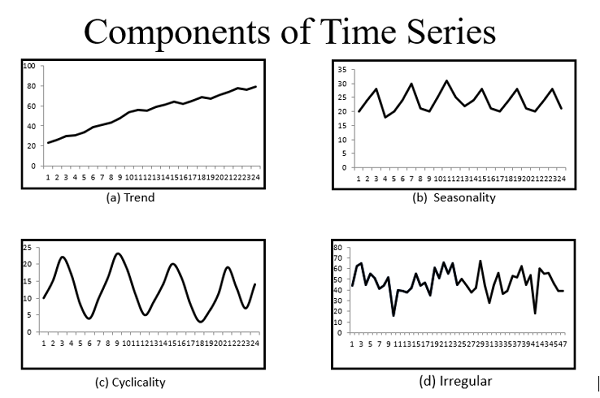

| 구성요소 | 설명 | 제조 데이터 예시 |
|---------|------|------------------|
| 추세 (Trend) | 장기적인 증가/감소 방향 | 설비 노후화로 인한 효율 저하 |
| 계절성 (Seasonality) | 일정 주기로 반복되는 패턴 | 주간/야간 교대 패턴, 계절별 생산량 |
| 잔차 (Residual) | 추세와 계절성으로 설명 불가능한 부분 | 돌발 이벤트, 측정 노이즈 |

## 1.3 일반 데이터 vs 시계열 데이터

시계열 데이터를 다룰 때는 일반적인 테이블 데이터와 다른 접근 방식이 필요함.

| 구분 | 일반 데이터 | 시계열 데이터 |
|------|------------|---------------|
| 행(row) 관계 | 각 행이 독립적 | 시간 순서로 연결됨 |
| 데이터 셔플 | 자유롭게 가능 | 시간 순서 파괴 - 의미 손실 |
| 학습/테스트 분할 | 랜덤 분할 가능 | **시간 기준 분할 필수** |
| 교차검증 방법 | K-Fold CV | **TimeSeriesSplit** |
| 특성 생성 | 현재 값 활용 가능 | **과거 데이터만 사용** |

### 왜 랜덤 분할이 문제가 되는가?

```
시간 순서: [1월]--[2월]--[3월]--[4월]--[5월]--[6월]

잘못된 분할 (랜덤):
  학습: [1월] [3월] [5월]
  테스트: [2월] [4월] [6월]  <- 미래 데이터로 과거를 예측하는 상황 발생!

올바른 분할 (시간 기준):
  학습: [1월] [2월] [3월] [4월]
  테스트: [5월] [6월]  <- 과거로 미래를 예측 (실제 상황과 동일)
```

랜덤 분할 시 발생하는 문제:
1. **데이터 누출(Data Leakage)**: 미래 정보가 학습에 포함됨
2. **과대평가된 성능**: 실제 예측 성능보다 높게 나타남
3. **실제 적용 실패**: 배포 시 성능이 급격히 저하됨

## 1.4 실습 환경 설정 및 데이터 로드

먼저 필요한 라이브러리를 임포트하고 한글 폰트를 설정함.

In [2]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (Colab 포함)
    # Colab에서 나눔고딕 설치
    import subprocess
    try:
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], 
                      capture_output=True, check=True)
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        print("한글 폰트 설치 실패. 기본 폰트 사용.")

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 랜덤 시드 고정
np.random.seed(94)

print("라이브러리 로드 완료")
print(f"NumPy 버전: {np.__version__}")
print(f"Pandas 버전: {pd.__version__}")

라이브러리 로드 완료
NumPy 버전: 2.4.0
Pandas 버전: 2.3.3


### 데이터 로드

Azure Predictive Maintenance Telemetry 데이터를 로드함. 전체 876,100건 중 실습 효율을 위해 **Machine ID 1번 기계의 데이터**를 추출하여 사용함.

In [3]:
# 데이터 로드 URL (GitHub Raw 파일)
DATA_URL = "https://raw.githubusercontent.com/microsoft/AMLWorkshop/master/Data/telemetry.csv"

print("[데이터 로드 시작]")
print(f"데이터 소스: Azure Predictive Maintenance Telemetry")
print(f"URL: {DATA_URL}")
print()

try:
    # 전체 데이터 로드
    df_full = pd.read_csv(DATA_URL)
    print(f"전체 데이터 로드 성공!")
    print(f"전체 레코드 수: {len(df_full):,}건")
    print(f"기계 수: {df_full['machineID'].nunique()}대")
    
    # Machine ID 1번 데이터 추출 (단일 기계 시계열 분석용)
    df = df_full[df_full['machineID'] == 1].copy()
    df = df.drop('machineID', axis=1)  # 단일 기계이므로 ID 컬럼 제거
    
    print(f"\n[분석 대상: Machine ID 1]")
    print(f"추출된 레코드 수: {len(df):,}건")
    
except Exception as e:
    print(f"[데이터 로드 실패: {e}]")
    print("\n대체 데이터를 생성합니다...")
    
    # 오프라인 대비 시뮬레이션 데이터 생성
    n = 8761  # 1년간 시간당 데이터
    dates = pd.date_range(start='2015-01-01 06:00:00', periods=n, freq='h')
    
    # 기본 값 + 추세 + 계절성 + 노이즈
    t = np.arange(n)
    daily_pattern = np.sin(2 * np.pi * t / 24)  # 일간 패턴
    weekly_pattern = np.sin(2 * np.pi * t / (24*7))  # 주간 패턴
    
    df = pd.DataFrame({
        'datetime': dates,
        'volt': 170 + 5 * daily_pattern + 10 * np.random.randn(n),
        'rotate': 450 + 20 * weekly_pattern + 50 * np.random.randn(n),
        'pressure': 100 + 10 * daily_pattern + 15 * np.random.randn(n),
        'vibration': 40 + 3 * daily_pattern + 5 * np.random.randn(n)
    })
    print(f"시뮬레이션 데이터 생성 완료: {len(df):,}건")

[데이터 로드 시작]
데이터 소스: Azure Predictive Maintenance Telemetry
URL: https://raw.githubusercontent.com/microsoft/AMLWorkshop/master/Data/telemetry.csv

전체 데이터 로드 성공!
전체 레코드 수: 876,100건
기계 수: 100대

[분석 대상: Machine ID 1]
추출된 레코드 수: 8,761건


### 데이터 기본 정보 확인

In [5]:
# datetime 파싱
df['datetime'] = pd.to_datetime(df['datetime'])

print("[데이터 구조]")
print(f"Shape: {df.shape}")
print(f"\n컬럼별 데이터 타입:")
print(df.dtypes)

print("\n" + "="*60)
print("="*60)
df.head(10)

[데이터 구조]
Shape: (8761, 5)

컬럼별 데이터 타입:
datetime     datetime64[ns]
volt                float64
rotate              float64
pressure            float64
vibration           float64
dtype: object



,datetime,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511
5,2015-01-01 11:00:00,172.504839,430.323362,95.927042,35.655017
6,2015-01-01 12:00:00,156.556031,499.071623,111.755684,42.753920
7,2015-01-01 13:00:00,172.522781,409.624717,101.001083,35.482009
8,2015-01-01 14:00:00,175.324524,398.648781,110.624361,45.482287
9,2015-01-01 15:00:00,169.218423,460.850670,104.848230,39.901735


In [6]:
# 기초 통계량
print("[센서별 기초 통계량]")
print("="*70)
df[['volt', 'rotate', 'pressure', 'vibration']].describe().round(2)

[센서별 기초 통계량]


,volt,rotate,pressure,vibration
count,8761.00,8761.00,8761.00,8761.00
mean,170.83,446.34,100.67,40.59
std,15.31,52.22,10.86,5.54
min,119.06,215.62,58.73,22.67
25%,160.38,412.35,93.32,36.85
50%,170.62,447.70,100.32,40.42
75%,180.93,481.36,107.38,44.00
max,237.94,636.36,155.26,67.63


In [8]:
# 결측치 확인
print("[결측치 현황]")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '결측치 수': missing,
    '비율(%)': missing_pct
})
print(missing_df)

if missing.sum() == 0:
    print("\n결측치가 없는 완전한 데이터셋")
else:
    print(f"\n총 결측치: {missing.sum()}개 ({missing.sum()/len(df)*100:.2f}%)")

[결측치 현황]
           결측치 수  비율(%)
datetime       0    0.0
volt           0    0.0
rotate         0    0.0
pressure       0    0.0
vibration      0    0.0

결측치가 없는 완전한 데이터셋


### 시계열 인덱스 설정

시계열 분석을 위해 datetime 컬럼을 인덱스로 설정함. 

Pandas의 DatetimeIndex를 활용하면 시간 기반 슬라이싱, 리샘플링 등 다양한 기능을 사용할 수 있음.

In [9]:
# datetime을 인덱스로 설정
df = df.set_index('datetime')

print("[시계열 인덱스 설정 완료]")
print(f"인덱스 타입: {type(df.index).__name__}")
print(f"데이터 기간: {df.index.min()} ~ {df.index.max()}")
print(f"총 기간: {(df.index.max() - df.index.min()).days}일")
print(f"데이터 간격: 매 시간")

print("\n[인덱스 설정 후 데이터]")
df.head()

[시계열 인덱스 설정 완료]
인덱스 타입: DatetimeIndex
데이터 기간: 2015-01-01 06:00:00 ~ 2016-01-01 06:00:00
총 기간: 365일
데이터 간격: 매 시간

[인덱스 설정 후 데이터]


,volt,rotate,pressure,vibration
datetime,,,,
2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686
2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973
2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847
2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144
2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511


## 1.5 시계열 시각화

시계열 데이터의 패턴을 파악하기 위한 다양한 시각화를 수행함.

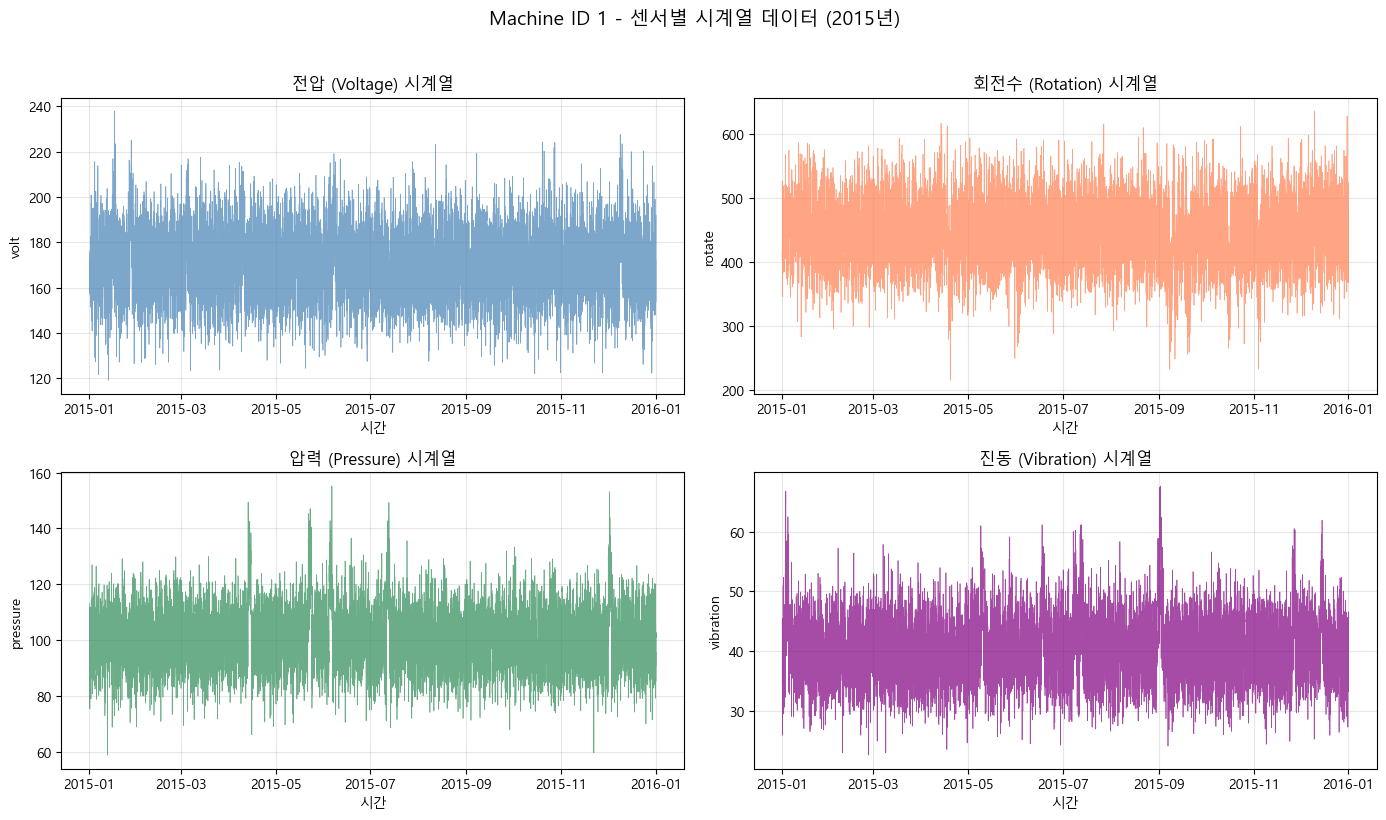

[시각화 해석]
- 각 센서는 시간에 따른 변동 패턴을 보임
- 일정한 범위 내에서 노이즈와 함께 측정됨
- 급격한 변화나 이상치가 있는지 확인 필요


In [10]:
# 4개 센서 시계열 플롯
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sensors = ['volt', 'rotate', 'pressure', 'vibration']
titles = ['전압 (Voltage)', '회전수 (Rotation)', '압력 (Pressure)', '진동 (Vibration)']
colors = ['steelblue', 'coral', 'seagreen', 'purple']

for ax, sensor, title, color in zip(axes.flatten(), sensors, titles, colors):
    ax.plot(df.index, df[sensor], linewidth=0.5, alpha=0.7, color=color)
    ax.set_title(f'{title} 시계열', fontsize=12)
    ax.set_xlabel('시간')
    ax.set_ylabel(sensor)
    ax.grid(True, alpha=0.3)

plt.suptitle('Machine ID 1 - 센서별 시계열 데이터 (2015년)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("[시각화 해석]")
print("- 각 센서는 시간에 따른 변동 패턴을 보임")
print("- 일정한 범위 내에서 노이즈와 함께 측정됨")
print("- 급격한 변화나 이상치가 있는지 확인 필요")

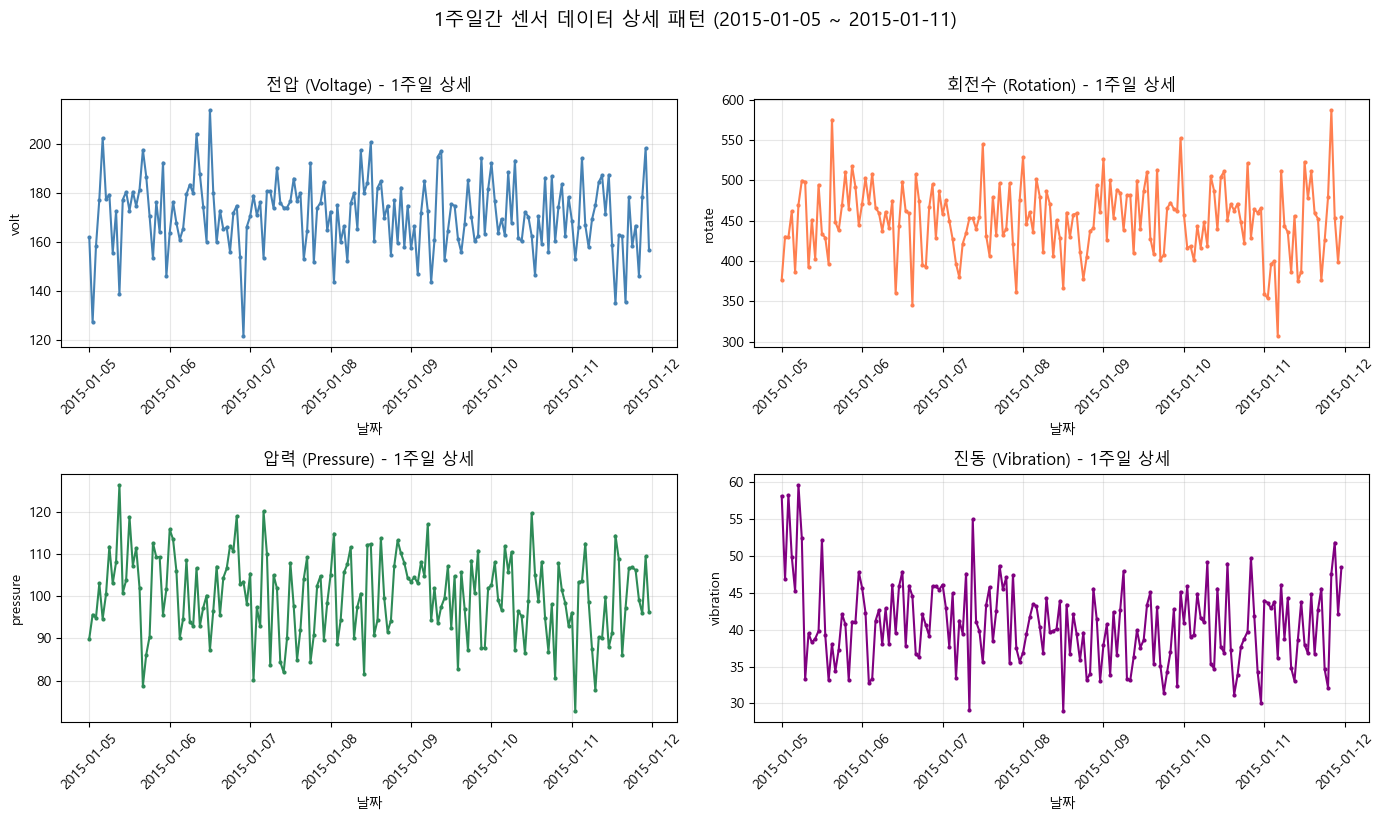

[1주일 상세 패턴 분석]
- 시간대별 변동 패턴 확인 가능
- 일간/주간 주기성이 있는지 관찰


In [11]:
# 1주일 데이터로 상세 패턴 확인
one_week = df['2015-01-05':'2015-01-11']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, sensor, title, color in zip(axes.flatten(), sensors, titles, colors):
    ax.plot(one_week.index, one_week[sensor], linewidth=1.5, 
            marker='o', markersize=2, color=color)
    ax.set_title(f'{title} - 1주일 상세', fontsize=12)
    ax.set_xlabel('날짜')
    ax.set_ylabel(sensor)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('1주일간 센서 데이터 상세 패턴 (2015-01-05 ~ 2015-01-11)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("[1주일 상세 패턴 분석]")
print("- 시간대별 변동 패턴 확인 가능")
print("- 일간/주간 주기성이 있는지 관찰")

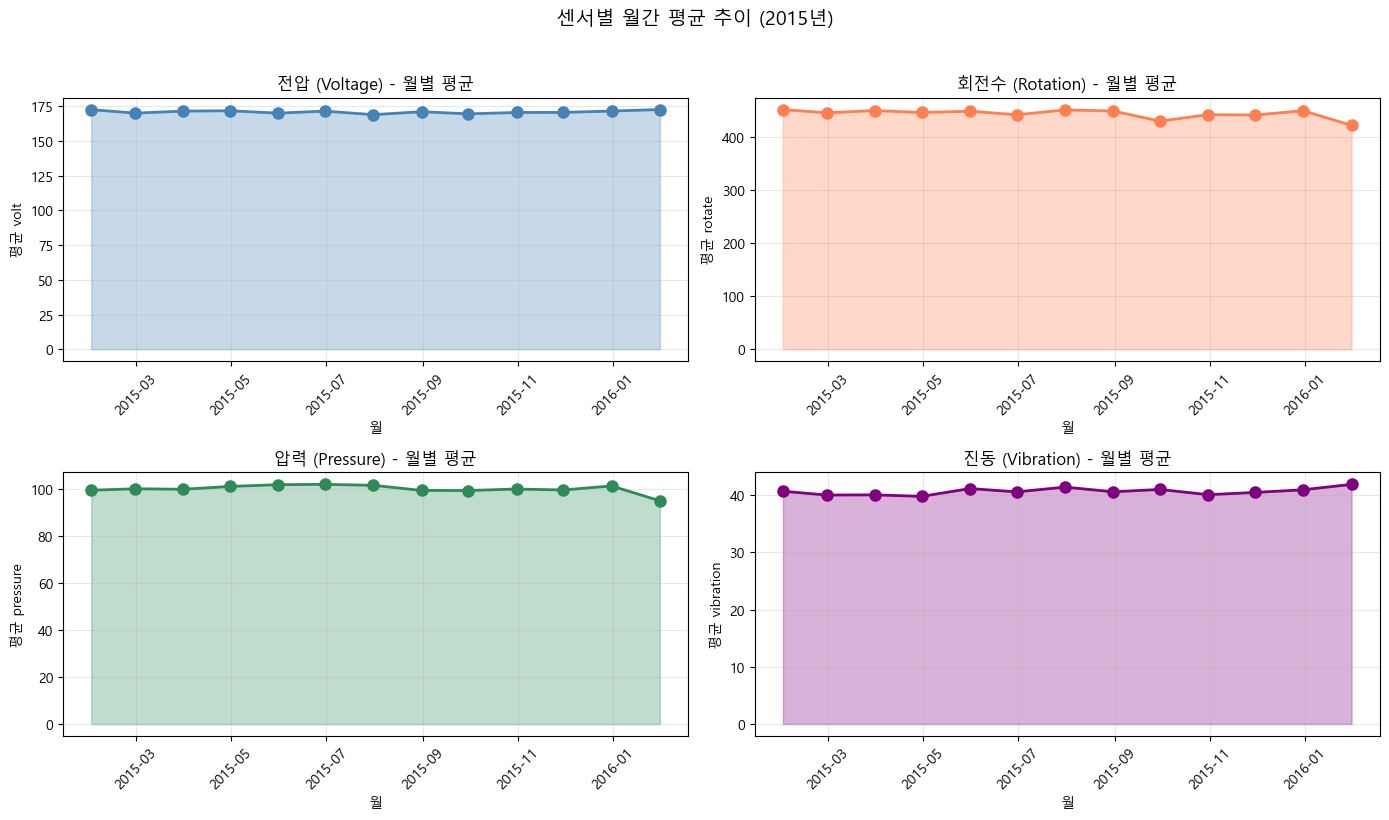

[월별 추이 분석]
- 연간 추세(증가/감소/안정) 파악
- 특정 월에 급격한 변화가 있는지 확인


In [12]:
# 월별 평균 트렌드 확인
monthly_mean = df.resample('ME').mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, sensor, title, color in zip(axes.flatten(), sensors, titles, colors):
    ax.plot(monthly_mean.index, monthly_mean[sensor], 
            linewidth=2, marker='o', markersize=8, color=color)
    ax.fill_between(monthly_mean.index, monthly_mean[sensor], alpha=0.3, color=color)
    ax.set_title(f'{title} - 월별 평균', fontsize=12)
    ax.set_xlabel('월')
    ax.set_ylabel(f'평균 {sensor}')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('센서별 월간 평균 추이 (2015년)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("[월별 추이 분석]")
print("- 연간 추세(증가/감소/안정) 파악")
print("- 특정 월에 급격한 변화가 있는지 확인")

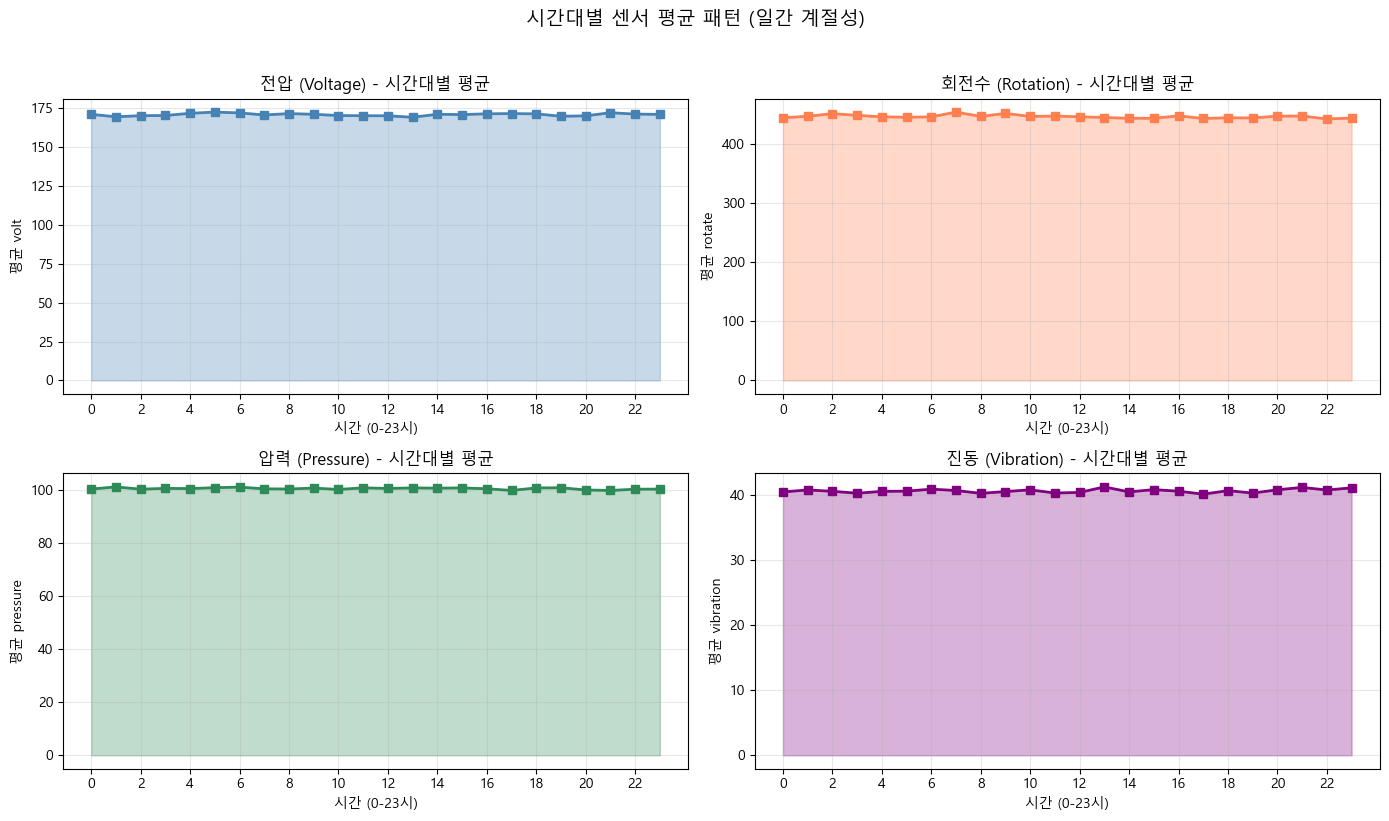

[시간대별 패턴 분석]
- 주간(낮)/야간(밤) 차이 확인
- 교대 근무 패턴 반영 여부


In [13]:
# 시간대별 패턴 (일간 계절성 확인)
df['hour'] = df.index.hour
hourly_pattern = df.groupby('hour')[sensors].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, sensor, title, color in zip(axes.flatten(), sensors, titles, colors):
    ax.plot(hourly_pattern.index, hourly_pattern[sensor], 
            linewidth=2, marker='s', markersize=6, color=color)
    ax.fill_between(hourly_pattern.index, hourly_pattern[sensor], alpha=0.3, color=color)
    ax.set_title(f'{title} - 시간대별 평균', fontsize=12)
    ax.set_xlabel('시간 (0-23시)')
    ax.set_ylabel(f'평균 {sensor}')
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)

plt.suptitle('시간대별 센서 평균 패턴 (일간 계절성)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# hour 컬럼 제거 (임시로 생성한 것)
df = df.drop('hour', axis=1)

print("[시간대별 패턴 분석]")
print("- 주간(낮)/야간(밤) 차이 확인")
print("- 교대 근무 패턴 반영 여부")

## 1.6 수학적 배경: !!이동평균과 지수평활!!

시계열 데이터의 노이즈를 제거하고 추세를 파악하기 위한 두 가지 핵심 기법을 학습함.

### 1.6.1 이동평균 (Moving Average)

이동평균은 연속된 $n$개 관측값의 평균을 계산하여 시계열을 평활화하는 기법임.

$$MA_t = \frac{1}{n} \sum_{i=0}^{n-1} X_{t-i} = \frac{X_t + X_{t-1} + \cdots + X_{t-n+1}}{n}$$

**기호 설명:**
- $MA_t$: 시점 $t$에서의 이동평균값
- $n$: 윈도우 크기 (평균에 포함되는 관측치 수)
- $X_{t-i}$: 시점 $t-i$에서의 관측값

**윈도우 크기의 영향:**

| 윈도우 크기 | 특징 | 용도 |
|:----------:|------|------|
| 작음 (3~5) | 원본에 가까움, 노이즈 일부 포함 | 단기 변동 관찰 |
| 중간 (7~14) | 균형잡힌 평활화 | 주간 패턴 제거 |
| 큼 (30+) | 매우 부드러움, 장기 추세만 표현 | 장기 추세 파악 |

**계산 예시 (윈도우 크기 = 3):**

```
원본:    [100, 110, 105, 115, 108, 120]
         |---------|  <- 첫 번째 윈도우
             |---------|  <- 두 번째 윈도우

MA_3 = (100 + 110 + 105) / 3 = 105.0
MA_4 = (110 + 105 + 115) / 3 = 110.0
MA_5 = (105 + 115 + 108) / 3 = 109.3
MA_6 = (115 + 108 + 120) / 3 = 114.3
```

In [14]:
# 이동평균 계산 예시 (전압 센서)
sample_data = df['volt'].iloc[:20].copy()

# 다양한 윈도우 크기로 이동평균 계산
ma_3 = sample_data.rolling(window=3).mean()
ma_5 = sample_data.rolling(window=5).mean()
ma_7 = sample_data.rolling(window=7).mean()

# 계산 과정 표시
print("[이동평균 계산 예시 - 전압 데이터]")
print("="*65)

result_df = pd.DataFrame({
    '원본(volt)': sample_data.round(2),
    'MA_3': ma_3.round(2),
    'MA_5': ma_5.round(2),
    'MA_7': ma_7.round(2)
})
print(result_df)

print("\n[수동 계산 검증 - MA_3의 4번째 값]")
idx = 3  # 0-indexed로 4번째
manual_calc = (sample_data.iloc[idx-2] + sample_data.iloc[idx-1] + sample_data.iloc[idx]) / 3
print(f"X[1] = {sample_data.iloc[idx-2]:.2f}")
print(f"X[2] = {sample_data.iloc[idx-1]:.2f}")
print(f"X[3] = {sample_data.iloc[idx]:.2f}")
print(f"MA_3 = ({sample_data.iloc[idx-2]:.2f} + {sample_data.iloc[idx-1]:.2f} + {sample_data.iloc[idx]:.2f}) / 3 = {manual_calc:.2f}")

[이동평균 계산 예시 - 전압 데이터]
                     원본(volt)    MA_3    MA_5    MA_7
datetime                                             
2015-01-01 06:00:00    176.22     NaN     NaN     NaN
2015-01-01 07:00:00    162.88     NaN     NaN     NaN
2015-01-01 08:00:00    170.99  170.03     NaN     NaN
2015-01-01 09:00:00    162.46  165.44     NaN     NaN
2015-01-01 10:00:00    157.61  163.69  166.03     NaN
2015-01-01 11:00:00    172.50  164.19  165.29     NaN
2015-01-01 12:00:00    156.56  162.22  164.02  165.60
2015-01-01 13:00:00    172.52  167.19  164.33  165.08
2015-01-01 14:00:00    175.32  168.13  166.90  166.85
2015-01-01 15:00:00    169.22  172.36  169.23  166.60
2015-01-01 16:00:00    167.06  170.53  168.14  167.26
2015-01-01 17:00:00    160.26  165.51  168.88  167.64
2015-01-01 18:00:00    153.35  160.23  165.04  164.90
2015-01-01 19:00:00    182.74  165.45  166.53  168.64
2015-01-01 20:00:00    170.34  168.81  166.75  168.33
2015-01-01 21:00:00    182.47  178.51  169.83  169.35
2015-0

### 1.6.2 지수평활 (Exponential Smoothing)

지수평활은 최근 관측값에 더 큰 가중치를 부여하는 평활 기법임. 과거로 갈수록 가중치가 지수적으로 감소함.

$$S_t = \alpha X_t + (1-\alpha) S_{t-1}$$

이를 전개하면:

$$S_t = \alpha X_t + \alpha(1-\alpha)X_{t-1} + \alpha(1-\alpha)^2 X_{t-2} + \cdots$$

**기호 설명:**
- $S_t$: 시점 $t$에서의 평활값
- $\alpha$: 평활 계수 (0 < $\alpha$ < 1)
- $X_t$: 현재 관측값
- $S_{t-1}$: 이전 평활값

**평활 계수 $\alpha$의 영향:**

| $\alpha$ 값 | 특징 | 적합한 상황 |
|:-----------:|------|------------|
| 작음 (0.1~0.3) | 과거 영향 큼, 매우 부드러움 | 안정적인 시계열 |
| 중간 (0.3~0.5) | 균형잡힌 반응 | 일반적인 경우 |
| 큼 (0.5~0.9) | 최근 영향 큼, 빠른 반응 | 변동이 큰 시계열 |

**계산 예시 ($\alpha = 0.3$):**

```
초기값: S_1 = X_1 = 100

X_2 = 110일 때:
S_2 = 0.3 × 110 + 0.7 × 100 = 33 + 70 = 103

X_3 = 105일 때:
S_3 = 0.3 × 105 + 0.7 × 103 = 31.5 + 72.1 = 103.6
```

In [15]:
# 지수평활 계산 예시
def exponential_smoothing(series, alpha):
    """지수평활 계산 함수"""
    result = [series.iloc[0]]  # 초기값은 첫 번째 관측값
    for i in range(1, len(series)):
        smoothed = alpha * series.iloc[i] + (1 - alpha) * result[-1]
        result.append(smoothed)
    return pd.Series(result, index=series.index)

# 다양한 alpha로 지수평활 계산
sample_data = df['volt'].iloc[:20].copy()

es_01 = exponential_smoothing(sample_data, alpha=0.1)
es_03 = exponential_smoothing(sample_data, alpha=0.3)
es_05 = exponential_smoothing(sample_data, alpha=0.5)
es_09 = exponential_smoothing(sample_data, alpha=0.9)

print("[지수평활 계산 예시 - 전압 데이터]")
print("="*75)

result_df = pd.DataFrame({
    '원본(volt)': sample_data.round(2),
    'ES(α=0.1)': es_01.round(2),
    'ES(α=0.3)': es_03.round(2),
    'ES(α=0.5)': es_05.round(2),
    'ES(α=0.9)': es_09.round(2)
})
print(result_df)

print("\n[수동 계산 검증 - α=0.3의 3번째 값]")
x1 = sample_data.iloc[0]
x2 = sample_data.iloc[1]
x3 = sample_data.iloc[2]
s1 = x1
s2 = 0.3 * x2 + 0.7 * s1
s3 = 0.3 * x3 + 0.7 * s2
print(f"S_1 = X_1 = {s1:.2f}")
print(f"S_2 = 0.3 × {x2:.2f} + 0.7 × {s1:.2f} = {s2:.2f}")
print(f"S_3 = 0.3 × {x3:.2f} + 0.7 × {s2:.2f} = {s3:.2f}")

[지수평활 계산 예시 - 전압 데이터]
                     원본(volt)  ES(α=0.1)  ES(α=0.3)  ES(α=0.5)  ES(α=0.9)
datetime                                                                 
2015-01-01 06:00:00    176.22     176.22     176.22     176.22     176.22
2015-01-01 07:00:00    162.88     174.88     172.22     169.55     164.21
2015-01-01 08:00:00    170.99     174.49     171.85     170.27     170.31
2015-01-01 09:00:00    162.46     173.29     169.03     166.37     163.25
2015-01-01 10:00:00    157.61     171.72     165.61     161.99     158.17
2015-01-01 11:00:00    172.50     171.80     167.68     167.25     171.07
2015-01-01 12:00:00    156.56     170.28     164.34     161.90     158.01
2015-01-01 13:00:00    172.52     170.50     166.79     167.21     171.07
2015-01-01 14:00:00    175.32     170.98     169.35     171.27     174.90
2015-01-01 15:00:00    169.22     170.81     169.31     170.24     169.79
2015-01-01 16:00:00    167.06     170.43     168.64     168.65     167.33
2015-01-01 17:00

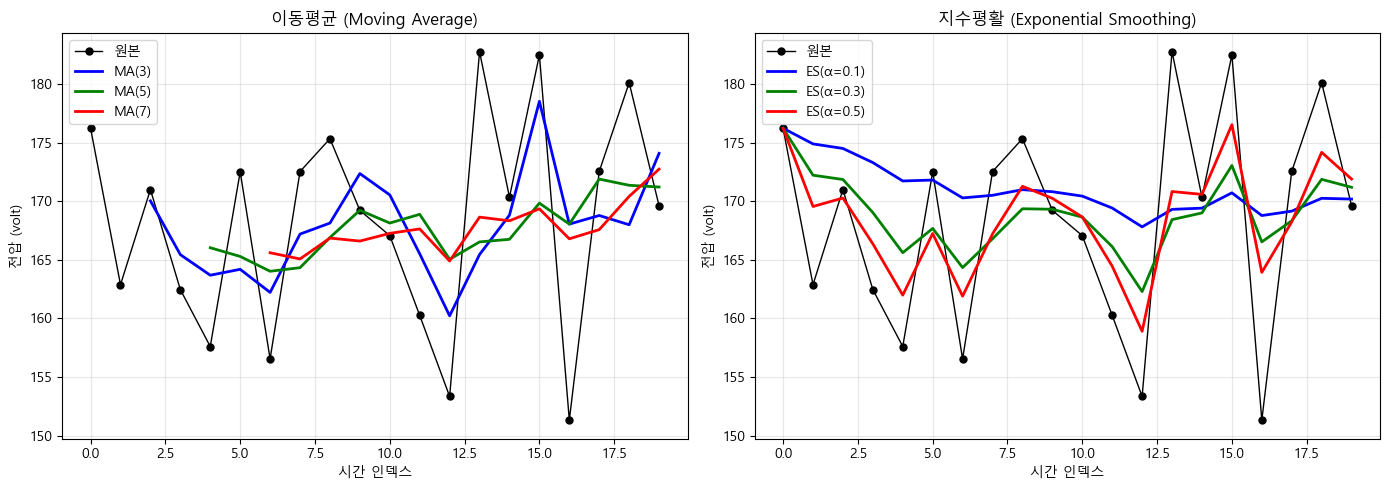

[비교 해석]
- 이동평균: 윈도우가 클수록 더 부드럽게 평활화됨
- 지수평활: α가 작을수록 더 부드럽게 평활화됨
- 지수평활은 첫 값부터 계산 가능 (이동평균은 n-1개 NaN 발생)


In [16]:
# 이동평균 vs 지수평활 시각화 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 + 이동평균
ax1 = axes[0]
ax1.plot(sample_data.values, 'ko-', label='원본', markersize=5, linewidth=1)
ax1.plot(ma_3.values, 'b-', label='MA(3)', linewidth=2)
ax1.plot(ma_5.values, 'g-', label='MA(5)', linewidth=2)
ax1.plot(ma_7.values, 'r-', label='MA(7)', linewidth=2)
ax1.set_title('이동평균 (Moving Average)', fontsize=12)
ax1.set_xlabel('시간 인덱스')
ax1.set_ylabel('전압 (volt)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 원본 + 지수평활
ax2 = axes[1]
ax2.plot(sample_data.values, 'ko-', label='원본', markersize=5, linewidth=1)
ax2.plot(es_01.values, 'b-', label='ES(α=0.1)', linewidth=2)
ax2.plot(es_03.values, 'g-', label='ES(α=0.3)', linewidth=2)
ax2.plot(es_05.values, 'r-', label='ES(α=0.5)', linewidth=2)
ax2.set_title('지수평활 (Exponential Smoothing)', fontsize=12)
ax2.set_xlabel('시간 인덱스')
ax2.set_ylabel('전압 (volt)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("[비교 해석]")
print("- 이동평균: 윈도우가 클수록 더 부드럽게 평활화됨")
print("- 지수평활: α가 작을수록 더 부드럽게 평활화됨")
print("- 지수평활은 첫 값부터 계산 가능 (이동평균은 n-1개 NaN 발생)")

### 1.6.3 !!!!!자기상관함수 (ACF: Autocorrelation Function)!!!!!!!

자기상관함수는 시계열과 자기 자신의 시차(lag) 버전 간의 상관관계를 측정함.

$$\rho_k = \frac{\sum_{t=k+1}^{n}(X_t - \bar{X})(X_{t-k} - \bar{X})}{\sum_{t=1}^{n}(X_t - \bar{X})^2}$$

**기호 설명:**
- $\rho_k$: 시차 $k$에서의 자기상관계수 (-1 ~ 1)
- $\bar{X}$: 시계열의 평균
- $n$: 전체 관측치 수
- $k$: 시차 (lag)

**자기상관 해석:**

| $\rho_k$ 값 | 의미 |
|:-----------:|------|
| 0.8 ~ 1.0 | 매우 강한 양의 상관 |
| 0.5 ~ 0.8 | 강한 양의 상관 |
| 0.2 ~ 0.5 | 중간 양의 상관 |
| -0.2 ~ 0.2 | 약한 상관 (거의 독립) |
| -0.5 ~ -0.2 | 중간 음의 상관 |
| -1.0 ~ -0.5 | 강한 음의 상관 |

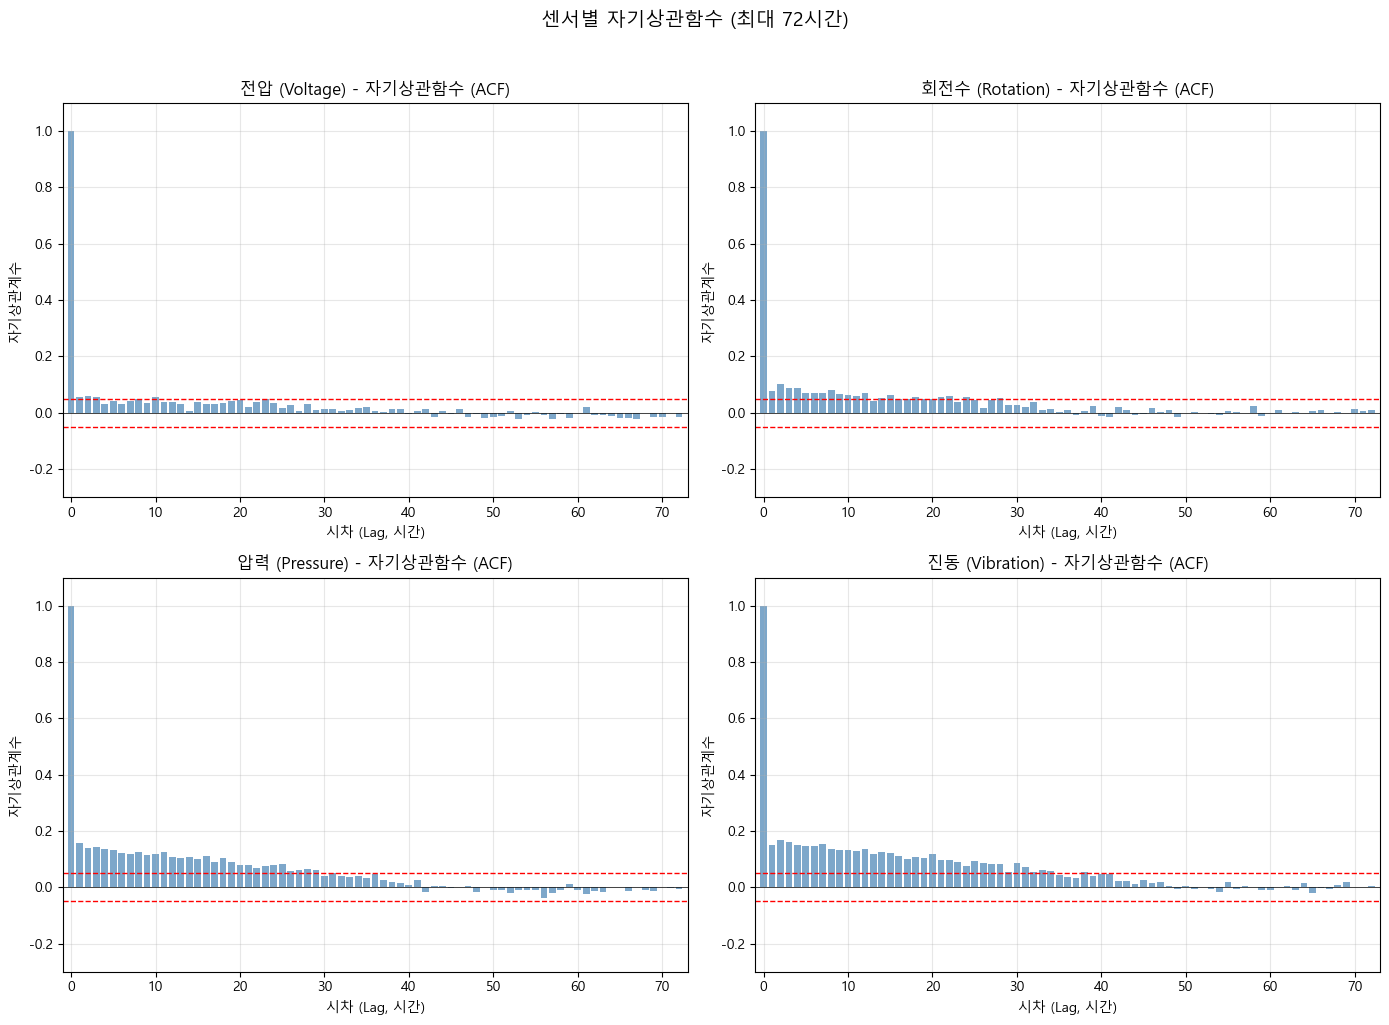

[자기상관 분석 결과]
전압 (Voltage):
  - Lag 1 (1시간 전): 0.057
  - Lag 24 (1일 전): 0.034
회전수 (Rotation):
  - Lag 1 (1시간 전): 0.078
  - Lag 24 (1일 전): 0.056
압력 (Pressure):
  - Lag 1 (1시간 전): 0.156
  - Lag 24 (1일 전): 0.077
진동 (Vibration):
  - Lag 1 (1시간 전): 0.152
  - Lag 24 (1일 전): 0.075


In [17]:
# 자기상관 계산 및 시각화
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, sensor, title in zip(axes.flatten(), sensors, titles):
    # 자기상관 계산 (최대 72시간 = 3일)
    acf_values = [df[sensor].autocorr(lag=i) for i in range(73)]
    
    ax.bar(range(73), acf_values, color='steelblue', alpha=0.7)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1, label='신뢰구간')
    ax.axhline(y=-0.05, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{title} - 자기상관함수 (ACF)', fontsize=12)
    ax.set_xlabel('시차 (Lag, 시간)')
    ax.set_ylabel('자기상관계수')
    ax.set_xlim(-1, 73)
    ax.set_ylim(-0.3, 1.1)
    ax.grid(True, alpha=0.3)

plt.suptitle('센서별 자기상관함수 (최대 72시간)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("[자기상관 분석 결과]")
print("="*60)
for sensor, title in zip(sensors, titles):
    acf_1 = df[sensor].autocorr(lag=1)
    acf_24 = df[sensor].autocorr(lag=24)
    print(f"{title}:")
    print(f"  - Lag 1 (1시간 전): {acf_1:.3f}")
    print(f"  - Lag 24 (1일 전): {acf_24:.3f}")

## 1.7 pandas datetime 처리

시계열 분석에서 datetime 처리는 핵심적인 기술임. pandas의 강력한 datetime 기능을 활용하는 방법을 학습함.

In [18]:
# 인덱스에서 날짜 정보 추출
print("[DatetimeIndex에서 날짜 정보 추출]")
print("="*50)

# 임시로 날짜 정보 컬럼 생성
date_info = pd.DataFrame(index=df.index)
date_info['year'] = df.index.year
date_info['month'] = df.index.month
date_info['day'] = df.index.day
date_info['hour'] = df.index.hour
date_info['dayofweek'] = df.index.dayofweek  # 0=월요일, 6=일요일
date_info['quarter'] = df.index.quarter
date_info['dayofyear'] = df.index.dayofyear
date_info['weekofyear'] = df.index.isocalendar().week.values

print("추출 가능한 정보:")
print(date_info.head(10))

[DatetimeIndex에서 날짜 정보 추출]
추출 가능한 정보:
                     year  month  day  hour  dayofweek  quarter  dayofyear  \
datetime                                                                     
2015-01-01 06:00:00  2015      1    1     6          3        1          1   
2015-01-01 07:00:00  2015      1    1     7          3        1          1   
2015-01-01 08:00:00  2015      1    1     8          3        1          1   
2015-01-01 09:00:00  2015      1    1     9          3        1          1   
2015-01-01 10:00:00  2015      1    1    10          3        1          1   
2015-01-01 11:00:00  2015      1    1    11          3        1          1   
2015-01-01 12:00:00  2015      1    1    12          3        1          1   
2015-01-01 13:00:00  2015      1    1    13          3        1          1   
2015-01-01 14:00:00  2015      1    1    14          3        1          1   
2015-01-01 15:00:00  2015      1    1    15          3        1          1   

                     week

In [22]:
# 날짜 기반 슬라이싱
print("[날짜 기반 슬라이싱 예시]")
print("="*50)

# 특정 날짜 범위
print("\n2015-06-15 ~ 2015-06-20 데이터:")
print(df['2015-06-15':'2015-06-20'].head(10))

# 특정 시간대
print("\n2015-07-01 오후 2시~6시 데이터:")
print(df['2015-07-01 14:00':'2015-07-01 18:00'])

[날짜 기반 슬라이싱 예시]

2015-06-15 ~ 2015-06-20 데이터:
                           volt      rotate    pressure  vibration
datetime                                                          
2015-06-15 00:00:00  160.003118  543.760558   94.833155  41.443009
2015-06-15 01:00:00  159.603007  387.565890   97.645085  42.956947
2015-06-15 02:00:00  161.978805  476.223593  101.930089  39.245919
2015-06-15 03:00:00  171.947189  370.195558   97.256941  36.557534
2015-06-15 04:00:00  173.178189  504.573467   99.991595  37.184005
2015-06-15 05:00:00  171.791798  416.064158   86.126689  40.624499
2015-06-15 06:00:00  192.836610  507.352663   94.916248  37.366488
2015-06-15 07:00:00  170.090649  488.984171  100.184867  35.161184
2015-06-15 08:00:00  176.563126  358.847505   98.884783  41.433667
2015-06-15 09:00:00  174.908371  421.459076   87.538044  35.978341

2015-07-01 오후 2시~6시 데이터:
                           volt      rotate    pressure  vibration
datetime                                                 

In [23]:
# resample을 이용한 주기 변환
print("[Resample을 이용한 주기 변환]")
print("="*50)

# 일별 평균
daily_mean = df.resample('D').mean()
print(f"\n시간당 -> 일별: {len(df)} -> {len(daily_mean)}건")
print(daily_mean.head())

# 주별 다양한 집계
weekly_agg = df['volt'].resample('W').agg(['mean', 'std', 'min', 'max'])
print(f"\n주별 전압 통계:")
print(weekly_agg.head(10))

[Resample을 이용한 주기 변환]

시간당 -> 일별: 8761 -> 366건
                  volt      rotate    pressure  vibration
datetime                                                 
2015-01-01  167.576533  440.515328   98.522345  40.049623
2015-01-02  169.795758  446.832666   98.454608  39.271645
2015-01-03  171.862244  459.204742   97.998233  48.074091
2015-01-04  174.792428  448.743201  101.452266  52.190268
2015-01-05  171.018408  454.822750  102.363114  43.330311

주별 전압 통계:
                  mean        std         min         max
datetime                                                 
2015-01-04  171.235421  14.668930  129.016707  215.656488
2015-01-11  170.868670  14.857720  121.502718  213.787102
2015-01-18  175.759659  19.169846  119.059047  237.938518
2015-01-25  167.748955  13.434507  127.034797  195.838277
2015-02-01  175.734767  17.604431  126.399891  225.189485
2015-02-08  169.273481  15.048943  126.889363  206.780952
2015-02-15  169.912442  14.177019  126.042769  202.345966
2015-02-22  17

# 2. 시계열 특성 엔지니어링

## 2.1 시계열 특성 엔지니어링이란?

시계열 특성 엔지니어링은 원본 시계열 데이터에서 머신러닝 모델이 학습할 수 있는 유의미한 특성(feature)을 생성하는 과정임.

### 특성 엔지니어링 워크플로우

```
+------------------+     +----------------------+     +------------------+
|   원본 시계열     | --> | 특성 엔지니어링       | --> |  특성 DataFrame   |
|   (datetime,     |     |                      |     |                  |
|    target)       |     | - 날짜 특성 추출     |     | (X: 특성들,      |
|                  |     | - !Lag 특성 생성!      |     |  y: 타겟)        |
|                  |     | - Rolling 특성 생성  |     |                  |
|                  |     | - 변화 특성 생성     |     |                  |
+------------------+     +----------------------+     +------------------+
                                   |
                                   v
                         +------------------+
                         | 데이터 누출 검증 |
                         | (shift 확인)     |
                         +------------------+
```

### 시계열 특성의 종류

| 종류 | 설명 | 예시 | 주의사항 |
|------|------|------|----------|
| 날짜 특성 | 시간에서 추출 | hour, dayofweek, month | 순환 인코딩 권장 |
| Lag 특성 | 과거 값 | lag_1, lag_24, lag_168 | **shift() 필수** |
| Rolling 특성 | 이동 통계 | ma_24, std_24 | **shift() 먼저 적용** |
| 변화 특성 | 변화량/변화율 | diff, pct_change | 과거 값 기준 계산 |

## 2.2 예측 대상 설정

본 실습에서는 **전압(volt) 센서 값을 예측**하는 회귀 문제를 다룸. 이는 제조 현장에서 다음 시점의 센서 값을 예측하여 이상 징후를 사전에 감지하는 데 활용될 수 있음.

In [24]:
# 예측 대상: 다음 시간의 전압 값
# 타겟 변수 설정
TARGET_COL = 'volt'

print(f"[예측 대상 설정]")
print(f"타겟 변수: {TARGET_COL}")
print(f"예측 목표: 다음 시간(t+1)의 전압 값 예측")
print(f"\n타겟 변수 기초 통계:")
print(df[TARGET_COL].describe().round(2))

[예측 대상 설정]
타겟 변수: volt
예측 목표: 다음 시간(t+1)의 전압 값 예측

타겟 변수 기초 통계:
count    8761.00
mean      170.83
std        15.31
min       119.06
25%       160.38
50%       170.62
75%       180.93
max       237.94
Name: volt, dtype: float64


## 2.3 날짜 특성 생성

시간 정보에서 유의미한 특성을 추출함. 특히 **순환 인코딩(Cyclic Encoding)** 을 적용하여 시간의 주기적 특성을 반영함.

In [26]:
# 특성 DataFrame 생성
features = pd.DataFrame(index=df.index)

# ===== 기본 날짜 특성 =====
features['year'] = df.index.year
features['month'] = df.index.month
features['day'] = df.index.day
features['hour'] = df.index.hour
features['dayofweek'] = df.index.dayofweek  # 0=월요일
features['quarter'] = df.index.quarter

print("[기본 날짜 특성]")
print(features.head(10))

[기본 날짜 특성]
                     year  month  day  hour  dayofweek  quarter
datetime                                                       
2015-01-01 06:00:00  2015      1    1     6          3        1
2015-01-01 07:00:00  2015      1    1     7          3        1
2015-01-01 08:00:00  2015      1    1     8          3        1
2015-01-01 09:00:00  2015      1    1     9          3        1
2015-01-01 10:00:00  2015      1    1    10          3        1
2015-01-01 11:00:00  2015      1    1    11          3        1
2015-01-01 12:00:00  2015      1    1    12          3        1
2015-01-01 13:00:00  2015      1    1    13          3        1
2015-01-01 14:00:00  2015      1    1    14          3        1
2015-01-01 15:00:00  2015      1    1    15          3        1


### 순환 인코딩 (Cyclic Encoding)

시간, 요일, 월 등의 순환적 특성을 sin/cos 변환을 통해 인코딩함.

**문제점**: 일반 정수 인코딩에서는 12월(12)과 1월(1)이 멀리 떨어져 있는 것처럼 인식됨.

**해결책**: sin/cos 변환을 통해 원형 좌표계에서 가까운 관계를 표현함.

$$x_{sin} = \sin\left(\frac{2\pi \cdot x}{max\_value}\right)$$

$$x_{cos} = \cos\left(\frac{2\pi \cdot x}{max\_value}\right)$$

예시 (시간):
- 23시: sin(2π×23/24) ≈ -0.26, cos(2π×23/24) ≈ 0.97
- 0시: sin(2π×0/24) = 0, cos(2π×0/24) = 1
- 1시: sin(2π×1/24) ≈ 0.26, cos(2π×1/24) ≈ 0.97

→ 23시와 1시가 0시를 중심으로 가깝게 표현됨

In [27]:
# ===== 순환 인코딩 =====

# 시간 (24시간 주기)
features['hour_sin'] = np.sin(2 * np.pi * features['hour'] / 24)
features['hour_cos'] = np.cos(2 * np.pi * features['hour'] / 24)

# 요일 (7일 주기)
features['dow_sin'] = np.sin(2 * np.pi * features['dayofweek'] / 7)
features['dow_cos'] = np.cos(2 * np.pi * features['dayofweek'] / 7)

# 월 (12개월 주기)
features['month_sin'] = np.sin(2 * np.pi * features['month'] / 12)
features['month_cos'] = np.cos(2 * np.pi * features['month'] / 12)

# 시간 순서 인덱스 (전체 추세 반영용)
features['time_idx'] = np.arange(len(df))

print("[순환 인코딩된 날짜 특성]")
print(features[['hour', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos']].head(10))

[순환 인코딩된 날짜 특성]
                     hour      hour_sin      hour_cos  month  month_sin  \
datetime                                                                  
2015-01-01 06:00:00     6  1.000000e+00  6.123234e-17      1        0.5   
2015-01-01 07:00:00     7  9.659258e-01 -2.588190e-01      1        0.5   
2015-01-01 08:00:00     8  8.660254e-01 -5.000000e-01      1        0.5   
2015-01-01 09:00:00     9  7.071068e-01 -7.071068e-01      1        0.5   
2015-01-01 10:00:00    10  5.000000e-01 -8.660254e-01      1        0.5   
2015-01-01 11:00:00    11  2.588190e-01 -9.659258e-01      1        0.5   
2015-01-01 12:00:00    12  1.224647e-16 -1.000000e+00      1        0.5   
2015-01-01 13:00:00    13 -2.588190e-01 -9.659258e-01      1        0.5   
2015-01-01 14:00:00    14 -5.000000e-01 -8.660254e-01      1        0.5   
2015-01-01 15:00:00    15 -7.071068e-01 -7.071068e-01      1        0.5   

                     month_cos  
datetime                        
2015-01-01 06:00:

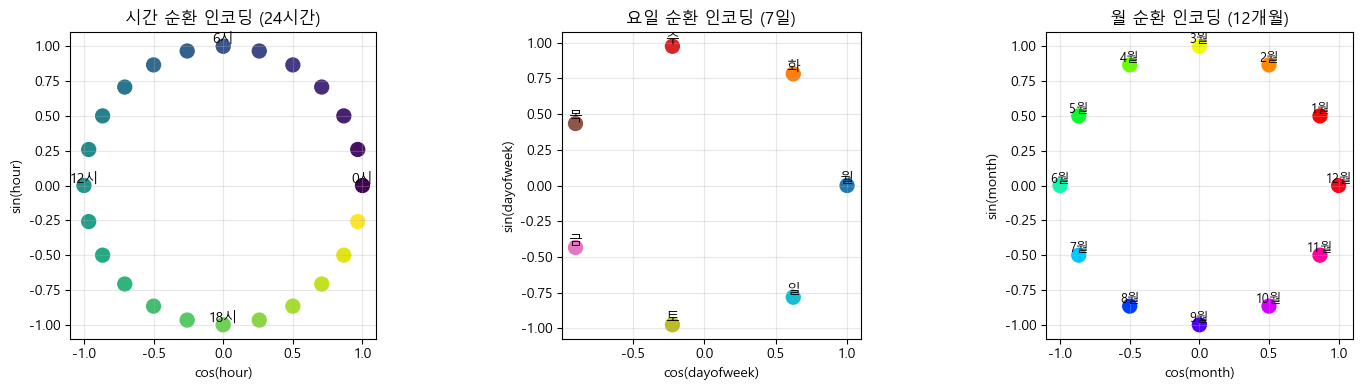

[순환 인코딩 효과]
- 23시와 0시, 1시가 원 위에서 가깝게 위치함
- 일요일과 월요일이 가깝게 위치함
- 12월과 1월이 가깝게 위치함


In [28]:
# 순환 인코딩 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 시간 순환 인코딩
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

ax1 = axes[0]
ax1.scatter(hour_cos, hour_sin, c=hours, cmap='viridis', s=100)
for h in [0, 6, 12, 18]:
    ax1.annotate(f'{h}시', (hour_cos[h], hour_sin[h]), fontsize=10, 
                ha='center', va='bottom')
ax1.set_xlabel('cos(hour)')
ax1.set_ylabel('sin(hour)')
ax1.set_title('시간 순환 인코딩 (24시간)')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# 요일 순환 인코딩
days = np.arange(7)
day_names = ['월', '화', '수', '목', '금', '토', '일']
dow_sin = np.sin(2 * np.pi * days / 7)
dow_cos = np.cos(2 * np.pi * days / 7)

ax2 = axes[1]
ax2.scatter(dow_cos, dow_sin, c=days, cmap='tab10', s=100)
for d, name in enumerate(day_names):
    ax2.annotate(name, (dow_cos[d], dow_sin[d]), fontsize=10, 
                ha='center', va='bottom')
ax2.set_xlabel('cos(dayofweek)')
ax2.set_ylabel('sin(dayofweek)')
ax2.set_title('요일 순환 인코딩 (7일)')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# 월 순환 인코딩
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

ax3 = axes[2]
ax3.scatter(month_cos, month_sin, c=months, cmap='hsv', s=100)
for m in months:
    ax3.annotate(f'{m}월', (month_cos[m-1], month_sin[m-1]), fontsize=9, 
                ha='center', va='bottom')
ax3.set_xlabel('cos(month)')
ax3.set_ylabel('sin(month)')
ax3.set_title('월 순환 인코딩 (12개월)')
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("[순환 인코딩 효과]")
print("- 23시와 0시, 1시가 원 위에서 가깝게 위치함")
print("- 일요일과 월요일이 가깝게 위치함")
print("- 12월과 1월이 가깝게 위치함")

## 2.4 Lag 특성 생성

**Lag 특성**은 과거 시점의 값을 현재 행의 특성으로 가져오는 것임. 시계열의 자기상관 특성을 활용함.

### shift() 함수의 동작 원리

```
원본:        [A, B, C, D, E]
shift(1):    [NaN, A, B, C, D]  <- 1시점 전 값
shift(2):    [NaN, NaN, A, B, C]  <- 2시점 전 값
shift(-1):   [B, C, D, E, NaN]  <- 미래 값 (사용 금지!)
```

**중요**: shift(n)에서 n은 양수여야 함. 음수는 미래 데이터를 가져오므로 데이터 누출 발생!

In [29]:
# ===== Lag 특성 생성 =====
# 예측에 사용할 센서 컬럼
sensor_cols = ['volt', 'rotate', 'pressure', 'vibration']

# Lag 시점 설정
lag_hours = [1, 2, 3, 6, 12, 24]  # 1시간, 2시간, ..., 24시간 전

print("[Lag 특성 생성]")
print(f"센서: {sensor_cols}")
print(f"Lag 시점: {lag_hours}")
print()

for col in sensor_cols:
    for lag in lag_hours:
        feature_name = f'{col}_lag_{lag}'
        features[feature_name] = df[col].shift(lag)
        
# 생성된 Lag 특성 확인
lag_cols = [c for c in features.columns if 'lag' in c]
print(f"생성된 Lag 특성 수: {len(lag_cols)}개")
print(f"\nLag 특성 목록 (처음 12개):")
for i, col in enumerate(lag_cols[:12], 1):
    print(f"  {i:2d}. {col}")

[Lag 특성 생성]
센서: ['volt', 'rotate', 'pressure', 'vibration']
Lag 시점: [1, 2, 3, 6, 12, 24]

생성된 Lag 특성 수: 24개

Lag 특성 목록 (처음 12개):
   1. volt_lag_1
   2. volt_lag_2
   3. volt_lag_3
   4. volt_lag_6
   5. volt_lag_12
   6. volt_lag_24
   7. rotate_lag_1
   8. rotate_lag_2
   9. rotate_lag_3
  10. rotate_lag_6
  11. rotate_lag_12
  12. rotate_lag_24


In [30]:
# Lag 특성 예시 확인 (전압)
print("[전압 Lag 특성 예시]")
volt_lag_cols = ['volt_lag_1', 'volt_lag_2', 'volt_lag_3', 'volt_lag_6', 'volt_lag_12', 'volt_lag_24']

example_df = pd.DataFrame({
    'volt(현재)': df['volt'],
    **{col: features[col] for col in volt_lag_cols}
})

print(example_df.iloc[24:30].round(2))

print("\n[해석]")
print("- volt_lag_1: 1시간 전 전압 값")
print("- volt_lag_24: 24시간(1일) 전 전압 값")
print("- NaN: 해당 시점에 과거 데이터가 없음")

[전압 Lag 특성 예시]
                     volt(현재)  volt_lag_1  volt_lag_2  volt_lag_3  volt_lag_6  \
datetime                                                                        
2015-01-02 06:00:00    197.36      181.26      200.87      158.27      180.10   
2015-01-02 07:00:00    171.20      197.36      181.26      200.87      169.61   
2015-01-02 08:00:00    160.53      171.20      197.36      181.26      167.13   
2015-01-02 09:00:00    147.30      160.53      171.20      197.36      158.27   
2015-01-02 10:00:00    160.46      147.30      160.53      171.20      200.87   
2015-01-02 11:00:00    173.39      160.46      147.30      160.53      181.26   

                     volt_lag_12  volt_lag_24  
datetime                                       
2015-01-02 06:00:00       153.35       176.22  
2015-01-02 07:00:00       182.74       162.88  
2015-01-02 08:00:00       170.34       170.99  
2015-01-02 09:00:00       182.47       162.46  
2015-01-02 10:00:00       151.34       157.61  


## 2.5 Rolling 특성 생성

**Rolling 특성**은 이동 윈도우 내의 통계량(평균, 표준편차, 최대, 최소 등)을 계산한 것임.

### 데이터 누출 방지를 위한 shift() 적용

Rolling 특성 생성 시 **반드시 shift(1)을 먼저 적용**해야 함. 그렇지 않으면 현재 값이 Rolling 계산에 포함되어 데이터 누출이 발생함.

```
잘못된 방법:
df['volt'].rolling(3).mean()  
-> 시점 t에서 (X_{t-2}, X_{t-1}, X_t)의 평균 = 현재 값 포함!

올바른 방법:
df['volt'].shift(1).rolling(3).mean()  
-> 시점 t에서 (X_{t-3}, X_{t-2}, X_{t-1})의 평균 = 과거 값만!
```

In [31]:
# ===== Rolling 특성 생성 =====
# Rolling 윈도우 크기 설정
windows = [3, 6, 12, 24]  # 3시간, 6시간, 12시간, 24시간

print("[Rolling 특성 생성]")
print(f"윈도우 크기: {windows}")
print("중요: shift(1) 먼저 적용하여 데이터 누출 방지!")
print()

for col in sensor_cols:
    # shift(1)로 과거 데이터만 사용
    shifted = df[col].shift(1)
    
    for window in windows:
        # 이동 평균
        features[f'{col}_ma_{window}'] = shifted.rolling(window).mean()
        # 이동 표준편차
        features[f'{col}_std_{window}'] = shifted.rolling(window).std()
        # 이동 최대값
        features[f'{col}_max_{window}'] = shifted.rolling(window).max()
        # 이동 최소값
        features[f'{col}_min_{window}'] = shifted.rolling(window).min()

# 생성된 Rolling 특성 확인
rolling_cols = [c for c in features.columns if any(x in c for x in ['_ma_', '_std_', '_max_', '_min_'])]
print(f"생성된 Rolling 특성 수: {len(rolling_cols)}개")
print(f"\nRolling 특성 종류:")
print(f"  - 이동 평균 (ma): {len([c for c in rolling_cols if '_ma_' in c])}개")
print(f"  - 이동 표준편차 (std): {len([c for c in rolling_cols if '_std_' in c])}개")
print(f"  - 이동 최대값 (max): {len([c for c in rolling_cols if '_max_' in c])}개")
print(f"  - 이동 최소값 (min): {len([c for c in rolling_cols if '_min_' in c])}개")

[Rolling 특성 생성]
윈도우 크기: [3, 6, 12, 24]
중요: shift(1) 먼저 적용하여 데이터 누출 방지!

생성된 Rolling 특성 수: 64개

Rolling 특성 종류:
  - 이동 평균 (ma): 16개
  - 이동 표준편차 (std): 16개
  - 이동 최대값 (max): 16개
  - 이동 최소값 (min): 16개


In [32]:
# 데이터 누출 방지 검증
print("[데이터 누출 방지 검증]")
print("="*70)

# 잘못된 방법과 올바른 방법 비교
sample = df['volt'].iloc[:10]

wrong_ma = sample.rolling(3).mean()  # 잘못된 방법
correct_ma = sample.shift(1).rolling(3).mean()  # 올바른 방법

comparison = pd.DataFrame({
    'volt(현재)': sample.round(2),
    '잘못된 MA(3)': wrong_ma.round(2),
    '올바른 MA(3)': correct_ma.round(2)
})
print(comparison)

print("\n[분석]")
print("- 잘못된 MA(3): 현재 값(X_t)이 평균에 포함됨 -> 데이터 누출!")
print("- 올바른 MA(3): 과거 값(X_{t-3}, X_{t-2}, X_{t-1})만 사용 -> 안전!")

print("\n[수동 검증 - 인덱스 4의 값]")
idx = 4
print(f"volt[2] = {sample.iloc[2]:.2f}")
print(f"volt[3] = {sample.iloc[3]:.2f}")
print(f"volt[4] = {sample.iloc[4]:.2f}")
print(f"\n잘못된 MA(3) = ({sample.iloc[2]:.2f} + {sample.iloc[3]:.2f} + {sample.iloc[4]:.2f}) / 3 = {wrong_ma.iloc[4]:.2f}")
print(f"올바른 MA(3) = ({sample.iloc[1]:.2f} + {sample.iloc[2]:.2f} + {sample.iloc[3]:.2f}) / 3 = {correct_ma.iloc[4]:.2f}")

[데이터 누출 방지 검증]
                     volt(현재)  잘못된 MA(3)  올바른 MA(3)
datetime                                           
2015-01-01 06:00:00    176.22        NaN        NaN
2015-01-01 07:00:00    162.88        NaN        NaN
2015-01-01 08:00:00    170.99     170.03        NaN
2015-01-01 09:00:00    162.46     165.44     170.03
2015-01-01 10:00:00    157.61     163.69     165.44
2015-01-01 11:00:00    172.50     164.19     163.69
2015-01-01 12:00:00    156.56     162.22     164.19
2015-01-01 13:00:00    172.52     167.19     162.22
2015-01-01 14:00:00    175.32     168.13     167.19
2015-01-01 15:00:00    169.22     172.36     168.13

[분석]
- 잘못된 MA(3): 현재 값(X_t)이 평균에 포함됨 -> 데이터 누출!
- 올바른 MA(3): 과거 값(X_{t-3}, X_{t-2}, X_{t-1})만 사용 -> 안전!

[수동 검증 - 인덱스 4의 값]
volt[2] = 170.99
volt[3] = 162.46
volt[4] = 157.61

잘못된 MA(3) = (170.99 + 162.46 + 157.61) / 3 = 163.69
올바른 MA(3) = (162.88 + 170.99 + 162.46) / 3 = 165.44


## 2.6 변화 특성 생성

**변화 특성**은 시간에 따른 값의 변화량이나 변화율을 나타냄. 급격한 변화를 감지하는 데 유용함.

In [33]:
# ===== 변화 특성 생성 =====
print("[변화 특성 생성]")

for col in sensor_cols:
    # 차분 (1시간 전 대비 변화량)
    features[f'{col}_diff_1'] = df[col].shift(1) - df[col].shift(2)
    
    # 24시간 전 대비 변화량
    features[f'{col}_diff_24'] = df[col].shift(1) - df[col].shift(25)
    
    # 변화율 (1시간 전 대비)
    features[f'{col}_pct_1'] = df[col].shift(1).pct_change()
    
    # 24시간 전 대비 비율
    features[f'{col}_ratio_24'] = df[col].shift(1) / df[col].shift(25)

# 생성된 변화 특성 확인
change_cols = [c for c in features.columns if any(x in c for x in ['_diff_', '_pct_', '_ratio_'])]
print(f"생성된 변화 특성 수: {len(change_cols)}개")

print(f"\n변화 특성 예시 (전압):")
volt_change = features[['volt_diff_1', 'volt_diff_24', 'volt_pct_1', 'volt_ratio_24']].iloc[25:30]
print(volt_change.round(4))

[변화 특성 생성]
생성된 변화 특성 수: 16개

변화 특성 예시 (전압):
                     volt_diff_1  volt_diff_24  volt_pct_1  volt_ratio_24
datetime                                                                 
2015-01-02 07:00:00      16.1056       21.1453      0.0889         1.1200
2015-01-02 08:00:00     -26.1622        8.3217     -0.1326         1.0511
2015-01-02 09:00:00     -10.6720      -10.4610     -0.0623         0.9388
2015-01-02 10:00:00     -13.2282      -15.1622     -0.0824         0.9067
2015-01-02 11:00:00      13.1578        2.8485      0.0893         1.0181


## 2.7 타겟 변수 설정 및 특성 요약

In [34]:
# 타겟 변수 추가 (현재 전압 값)
features['target'] = df[TARGET_COL]

print("[전체 특성 요약]")
print("="*60)

# 특성 카테고리별 개수
date_cols = ['year', 'month', 'day', 'hour', 'dayofweek', 'quarter',
             'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 
             'month_sin', 'month_cos', 'time_idx']
lag_cols = [c for c in features.columns if 'lag' in c]
rolling_cols = [c for c in features.columns if any(x in c for x in ['_ma_', '_std_', '_max_', '_min_'])]
change_cols = [c for c in features.columns if any(x in c for x in ['_diff_', '_pct_', '_ratio_'])]

print(f"{'카테고리':<20} {'개수':>10}")
print("-"*32)
print(f"{'날짜 특성':<20} {len(date_cols):>10}")
print(f"{'Lag 특성':<20} {len(lag_cols):>10}")
print(f"{'Rolling 특성':<20} {len(rolling_cols):>10}")
print(f"{'변화 특성':<20} {len(change_cols):>10}")
print("-"*32)
print(f"{'총 특성 수':<20} {len(features.columns)-1:>10}")  # 타겟 제외

print(f"\n[데이터 Shape]")
print(f"특성 DataFrame: {features.shape}")

[전체 특성 요약]
카테고리                         개수
--------------------------------
날짜 특성                        13
Lag 특성                       24
Rolling 특성                   64
변화 특성                        16
--------------------------------
총 특성 수                      117

[데이터 Shape]
특성 DataFrame: (8761, 118)


In [35]:
# NaN 확인 및 제거
print("[NaN 현황]")
nan_counts = features.isnull().sum()
nan_cols = nan_counts[nan_counts > 0]

print(f"NaN이 있는 컬럼 수: {len(nan_cols)}개")
print(f"최대 NaN 개수: {nan_counts.max()}개")

# NaN 제거
features_clean = features.dropna()

print(f"\n[NaN 제거 결과]")
print(f"원본: {len(features):,}행")
print(f"정제 후: {len(features_clean):,}행")
print(f"제거된 행: {len(features) - len(features_clean):,}행 ({(len(features) - len(features_clean))/len(features)*100:.1f}%)")

[NaN 현황]
NaN이 있는 컬럼 수: 104개
최대 NaN 개수: 25개

[NaN 제거 결과]
원본: 8,761행
정제 후: 8,736행
제거된 행: 25행 (0.3%)


# 3머 신러닝 기반 예측 및 평가

## 3.1 데이터 분할: 시간 기준 분할

시계열 데이터에서는 **반드시 시간 순서를 유지한 분할**을 수행해야 함. 과거 데이터로 학습하고 미래 데이터로 테스트하는 것이 실제 상황과 동일함.

In [36]:
# 시간 기준 분할
# 2015년 1월~10월: 학습, 11월~12월: 테스트
SPLIT_DATE = '2015-11-01'

# 특성과 타겟 분리
X = features_clean.drop('target', axis=1)
y = features_clean['target']

# 시간 기준 분할
X_train = X[X.index < SPLIT_DATE]
X_test = X[X.index >= SPLIT_DATE]
y_train = y[y.index < SPLIT_DATE]
y_test = y[y.index >= SPLIT_DATE]

print("[시간 기준 데이터 분할]")
print("="*60)
print(f"분할 기준일: {SPLIT_DATE}")
print(f"\n학습 데이터:")
print(f"  - 기간: {X_train.index.min()} ~ {X_train.index.max()}")
print(f"  - 샘플 수: {len(X_train):,}개 ({len(X_train)/len(X)*100:.1f}%)")
print(f"\n테스트 데이터:")
print(f"  - 기간: {X_test.index.min()} ~ {X_test.index.max()}")
print(f"  - 샘플 수: {len(X_test):,}개 ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n특성 수: {X_train.shape[1]}개")

[시간 기준 데이터 분할]
분할 기준일: 2015-11-01

학습 데이터:
  - 기간: 2015-01-02 07:00:00 ~ 2015-10-31 23:00:00
  - 샘플 수: 7,265개 (83.2%)

테스트 데이터:
  - 기간: 2015-11-01 00:00:00 ~ 2016-01-01 06:00:00
  - 샘플 수: 1,471개 (16.8%)

특성 수: 117개


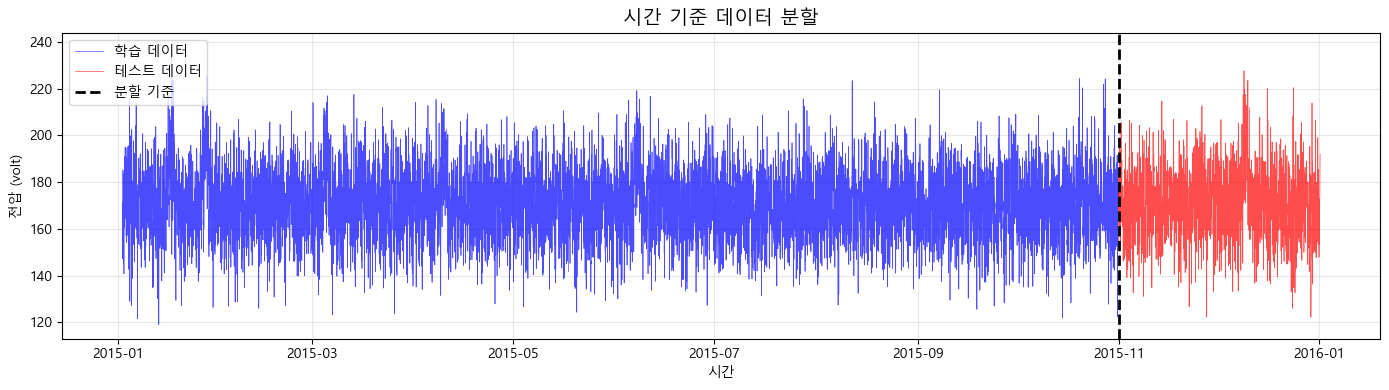

[분할 원칙]
- 학습 데이터: 과거 데이터 (파란색)
- 테스트 데이터: 미래 데이터 (빨간색)
- 실제 예측 상황과 동일한 조건에서 평가


In [37]:
# 분할 시각화
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(y_train.index, y_train.values, 'b-', linewidth=0.5, label='학습 데이터', alpha=0.7)
ax.plot(y_test.index, y_test.values, 'r-', linewidth=0.5, label='테스트 데이터', alpha=0.7)
ax.axvline(x=pd.Timestamp(SPLIT_DATE), color='black', linestyle='--', linewidth=2, label='분할 기준')

ax.set_title('시간 기준 데이터 분할', fontsize=14)
ax.set_xlabel('시간')
ax.set_ylabel('전압 (volt)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("[분할 원칙]")
print("- 학습 데이터: 과거 데이터 (파란색)")
print("- 테스트 데이터: 미래 데이터 (빨간색)")
print("- 실제 예측 상황과 동일한 조건에서 평가")

## 3.2 시계열 평가 지표

시계열 예측 모델의 성능을 평가하기 위한 주요 지표를 학습함.

### 평가 지표 정의

| 지표 | 수식 | 특징 |
|------|------|------|
| MAE (Mean Absolute Error) | $\frac{1}{n}\sum_{i=1}^{n}\|y_i - \hat{y}_i\|$ | 해석 쉬움, 단위 동일 |
| MSE (Mean Squared Error) | $\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ | 큰 오차에 패널티 |
| RMSE (Root MSE) | $\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$ | MSE의 제곱근, 단위 동일 |
| MAPE (Mean Absolute Percentage Error) | $\frac{100}{n}\sum_{i=1}^{n}\frac{\|y_i - \hat{y}_i\|}{y_i}$ | 상대적 오차 (%) |
| R² (Coefficient of Determination) | $1 - \frac{SS_{res}}{SS_{tot}}$ | 설명력 (0~1) |

### MAPE 해석 기준

| MAPE 범위 | 해석 |
|:---------:|------|
| 0-5% | 매우 우수한 예측 |
| 5-10% | 좋은 예측 |
| 10-20% | 보통 수준 |
| 20% 초과 | 개선 필요 |

In [38]:
# 평가 지표 함수 정의
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_metrics(y_true, y_pred):
    """
    시계열 예측 평가 지표 계산
    
    Parameters:
    -----------
    y_true : array-like
        실제값
    y_pred : array-like
        예측값
    
    Returns:
    --------
    dict : 평가 지표 딕셔너리
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (0 값 제외)
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

def print_metrics(metrics, model_name="Model"):
    """평가 지표 출력"""
    print(f"[{model_name} 평가 결과]")
    print("="*40)
    print(f"MAE:  {metrics['MAE']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    print(f"R²:   {metrics['R2']:.4f}")
    
    # MAPE 기준 해석
    if metrics['MAPE'] < 5:
        interpretation = "매우 우수한 예측 성능"
    elif metrics['MAPE'] < 10:
        interpretation = "좋은 예측 성능"
    elif metrics['MAPE'] < 20:
        interpretation = "보통 수준의 예측 성능"
    else:
        interpretation = "개선이 필요한 예측 성능"
    print(f"\n해석: {interpretation}")

print("평가 함수 정의 완료")

평가 함수 정의 완료


## 3.3 RandomForest 모델 학습

RandomForest는 앙상블 학습 방법 중 하나로, 시계열 회귀 문제에서 좋은 성능을 보이는 모델임.

In [39]:
from sklearn.ensemble import RandomForestRegressor

# RandomForest 모델 정의
rf_model = RandomForestRegressor(
    n_estimators=100,        # 트리 개수
    max_depth=15,            # 최대 깊이
    min_samples_split=10,    # 분할 최소 샘플
    min_samples_leaf=5,      # 리프 최소 샘플
    random_state=42,
    n_jobs=-1                # 병렬 처리
)

print("[RandomForest 모델 학습]")
print("="*50)
print("하이퍼파라미터:")
print(f"  - n_estimators: {rf_model.n_estimators}")
print(f"  - max_depth: {rf_model.max_depth}")
print(f"  - min_samples_split: {rf_model.min_samples_split}")
print(f"  - min_samples_leaf: {rf_model.min_samples_leaf}")

# 모델 학습
import time
start_time = time.time()

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"\n학습 완료! (소요 시간: {training_time:.2f}초)")

[RandomForest 모델 학습]
하이퍼파라미터:
  - n_estimators: 100
  - max_depth: 15
  - min_samples_split: 10
  - min_samples_leaf: 5

학습 완료! (소요 시간: 2.95초)


In [40]:
# 예측 수행
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 평가
print("[학습 데이터 평가]")
train_metrics = calculate_metrics(y_train.values, y_train_pred)
print_metrics(train_metrics, "RandomForest (Train)")

print("\n" + "="*50)

print("\n[테스트 데이터 평가]")
test_metrics = calculate_metrics(y_test.values, y_test_pred)
print_metrics(test_metrics, "RandomForest (Test)")

# 과적합 체크
print("\n" + "="*50)
print("\n[과적합 체크]")
r2_gap = train_metrics['R2'] - test_metrics['R2']
print(f"R² 차이 (Train - Test): {r2_gap:.4f}")
if r2_gap > 0.1:
    print("-> 과적합 가능성 있음. 정규화 또는 하이퍼파라미터 조정 권장")
else:
    print("-> 과적합 없음. 적절한 일반화 성능")

[학습 데이터 평가]
[RandomForest (Train) 평가 결과]
MAE:  8.9467
RMSE: 11.2735
MAPE: 5.33%
R²:   0.4582

해석: 좋은 예측 성능


[테스트 데이터 평가]
[RandomForest (Test) 평가 결과]
MAE:  12.1020
RMSE: 15.1870
MAPE: 7.14%
R²:   0.0212

해석: 좋은 예측 성능


[과적합 체크]
R² 차이 (Train - Test): 0.4370
-> 과적합 가능성 있음. 정규화 또는 하이퍼파라미터 조정 권장


## 3.4 특성 중요도 분석

어떤 특성이 예측에 가장 크게 기여하는지 분석함.

In [41]:
# 특성 중요도 계산
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("[특성 중요도 Top 20]")
print("="*50)
print(importance_df.head(20).to_string(index=False))

[특성 중요도 Top 20]
         feature  importance
      volt_ma_12    0.096316
vibration_lag_24    0.018908
    rotate_lag_6    0.013066
     volt_lag_24    0.012882
     volt_std_12    0.012514
      volt_lag_6    0.012242
   rotate_lag_12    0.012150
 pressure_lag_12    0.011674
  pressure_lag_3    0.011624
     volt_lag_12    0.011593
  pressure_lag_6    0.011528
  pressure_std_3    0.011096
 vibration_lag_3    0.010855
 pressure_lag_24    0.010849
    rotate_std_6    0.010834
       volt_ma_3    0.010806
      volt_lag_2    0.010794
     volt_std_24    0.010672
vibration_lag_12    0.010501
  pressure_lag_2    0.010472


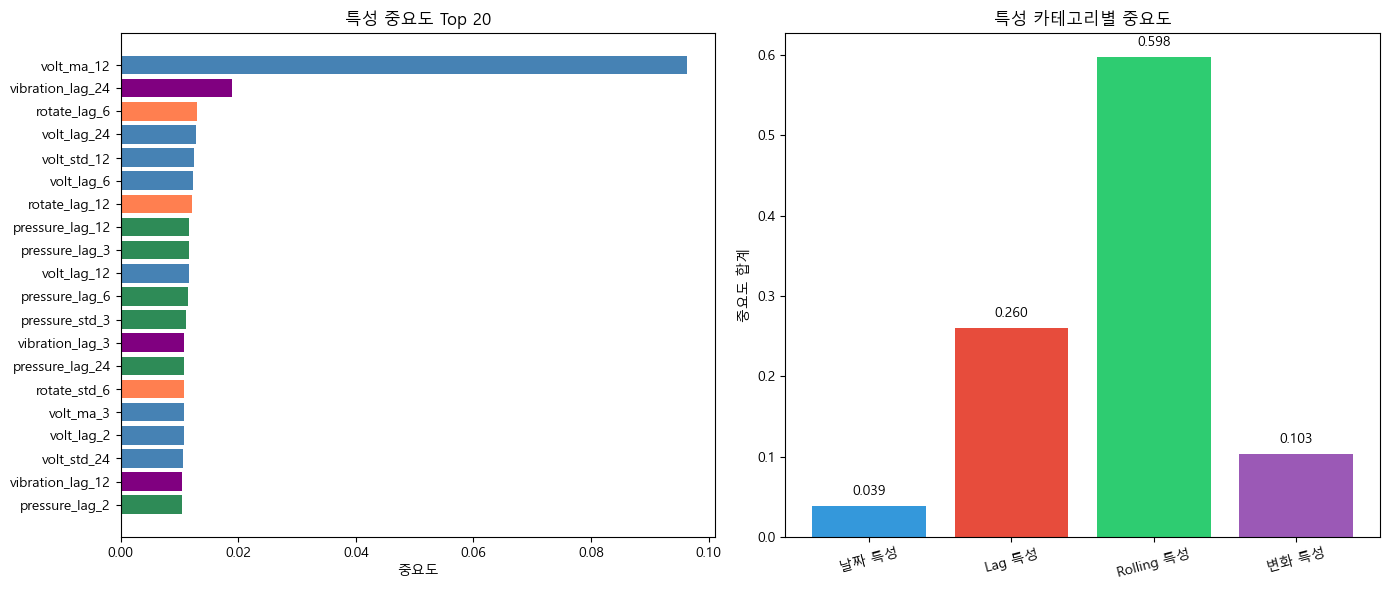

[특성 중요도 분석 결과]
- 가장 중요한 특성: volt_ma_12 (0.0963)
- Lag 특성이 전체의 26.0%를 차지
- 시계열 예측에서 과거 값(Lag)이 가장 중요한 정보임을 확인


In [42]:
# 특성 중요도 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 20 특성 중요도
top_n = 20
top_features = importance_df.head(top_n)

ax1 = axes[0]
colors = ['steelblue' if 'volt' in f else 'coral' if 'rotate' in f 
          else 'seagreen' if 'pressure' in f else 'purple' if 'vibration' in f
          else 'gray' for f in top_features['feature']]

ax1.barh(range(top_n), top_features['importance'].values, color=colors)
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(top_features['feature'].values)
ax1.set_xlabel('중요도')
ax1.set_title(f'특성 중요도 Top {top_n}')
ax1.invert_yaxis()

# 특성 카테고리별 중요도 합계
category_importance = {
    '날짜 특성': importance_df[importance_df['feature'].isin(date_cols)]['importance'].sum(),
    'Lag 특성': importance_df[importance_df['feature'].str.contains('lag')]['importance'].sum(),
    'Rolling 특성': importance_df[importance_df['feature'].str.contains('ma_|std_|max_|min_')]['importance'].sum(),
    '변화 특성': importance_df[importance_df['feature'].str.contains('diff_|pct_|ratio_')]['importance'].sum()
}

ax2 = axes[1]
categories = list(category_importance.keys())
values = list(category_importance.values())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

bars = ax2.bar(categories, values, color=colors)
ax2.set_ylabel('중요도 합계')
ax2.set_title('특성 카테고리별 중요도')
ax2.tick_params(axis='x', rotation=15)

# 값 표시
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("[특성 중요도 분석 결과]")
print(f"- 가장 중요한 특성: {importance_df.iloc[0]['feature']} ({importance_df.iloc[0]['importance']:.4f})")
print(f"- Lag 특성이 전체의 {category_importance['Lag 특성']*100:.1f}%를 차지")
print("- 시계열 예측에서 과거 값(Lag)이 가장 중요한 정보임을 확인")

## 3.5 예측 결과 시각화

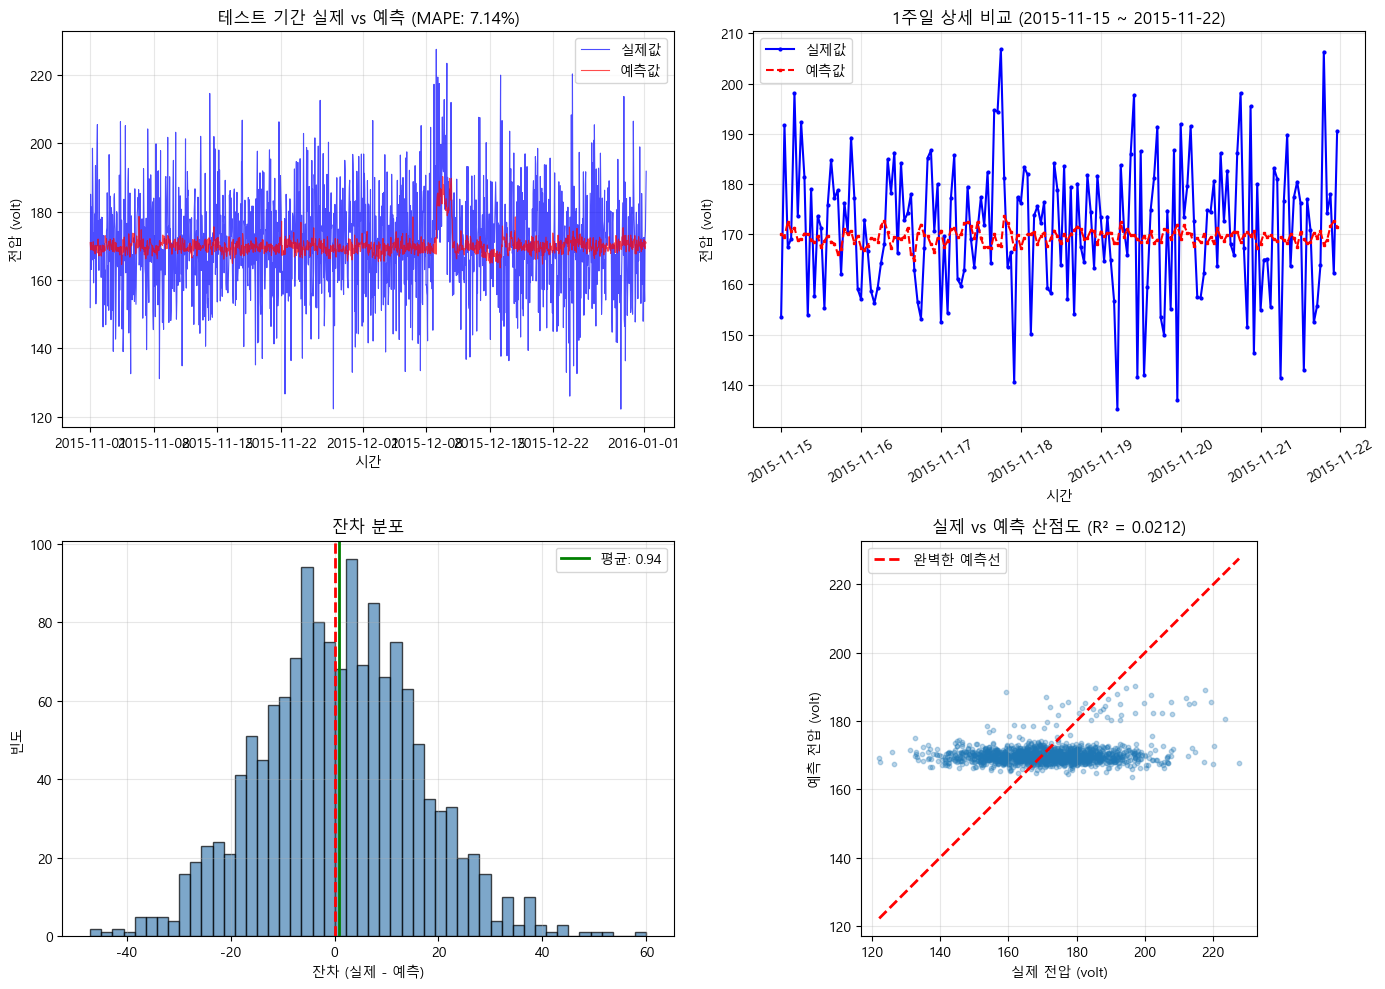

[시각화 해석]
1. 실제 vs 예측: 전반적인 패턴을 잘 따라감
2. 1주일 상세: 시간대별 변동을 적절히 예측
3. 잔차 분포: 0 중심의 정규분포에 가까우면 좋은 모델
4. 산점도: 대각선에 가까울수록 예측 정확


In [43]:
# 예측 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 전체 기간 실제 vs 예측
ax1 = axes[0, 0]
ax1.plot(y_test.index, y_test.values, 'b-', linewidth=0.8, label='실제값', alpha=0.7)
ax1.plot(y_test.index, y_test_pred, 'r-', linewidth=0.8, label='예측값', alpha=0.7)
ax1.set_title(f'테스트 기간 실제 vs 예측 (MAPE: {test_metrics["MAPE"]:.2f}%)', fontsize=12)
ax1.set_xlabel('시간')
ax1.set_ylabel('전압 (volt)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 1주일 상세 비교
ax2 = axes[0, 1]
week_start = '2015-11-15'
week_end = '2015-11-22'
mask = (y_test.index >= week_start) & (y_test.index < week_end)

ax2.plot(y_test.index[mask], y_test.values[mask], 'b-', linewidth=1.5, 
         marker='o', markersize=2, label='실제값')
ax2.plot(y_test.index[mask], y_test_pred[mask], 'r--', linewidth=1.5, 
         marker='s', markersize=2, label='예측값')
ax2.set_title('1주일 상세 비교 (2015-11-15 ~ 2015-11-22)', fontsize=12)
ax2.set_xlabel('시간')
ax2.set_ylabel('전압 (volt)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=30)

# 3. 잔차 분포
ax3 = axes[1, 0]
residuals = y_test.values - y_test_pred
ax3.hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.axvline(x=np.mean(residuals), color='green', linestyle='-', linewidth=2, 
            label=f'평균: {np.mean(residuals):.2f}')
ax3.set_title('잔차 분포', fontsize=12)
ax3.set_xlabel('잔차 (실제 - 예측)')
ax3.set_ylabel('빈도')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 실제 vs 예측 산점도
ax4 = axes[1, 1]
ax4.scatter(y_test.values, y_test_pred, alpha=0.3, s=10)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='완벽한 예측선')
ax4.set_title(f'실제 vs 예측 산점도 (R² = {test_metrics["R2"]:.4f})', fontsize=12)
ax4.set_xlabel('실제 전압 (volt)')
ax4.set_ylabel('예측 전압 (volt)')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_aspect('equal')

plt.tight_layout()
plt.show()

print("[시각화 해석]")
print("1. 실제 vs 예측: 전반적인 패턴을 잘 따라감")
print("2. 1주일 상세: 시간대별 변동을 적절히 예측")
print("3. 잔차 분포: 0 중심의 정규분포에 가까우면 좋은 모델")
print("4. 산점도: 대각선에 가까울수록 예측 정확")

## 3.6 TimeSeriesSplit 교차검증

시계열 데이터에 적합한 교차검증 방법인 **TimeSeriesSplit**을 적용함. 이 방법은 항상 과거 데이터로 학습하고 미래 데이터로 검증하는 방식을 유지함.

### TimeSeriesSplit vs K-Fold 비교

```
[K-Fold (5-Fold)] - 시계열에 부적합!
Fold 1: [V V V] [T T T T T T T T T T T T]  <- 무작위 선택
Fold 2: [T T T] [V V V] [T T T T T T T T T]
...

[TimeSeriesSplit (5-Fold)] - 시계열에 적합!
Fold 1: [T T T T T T T T] [V V]           <- 시간 순서 유지
Fold 2: [T T T T T T T T T T] [V V]
Fold 3: [T T T T T T T T T T T T] [V V]
Fold 4: [T T T T T T T T T T T T T T] [V V]
Fold 5: [T T T T T T T T T T T T T T T T] [V V]

T = Train (과거), V = Validation (미래)
```

In [44]:
from sklearn.model_selection import TimeSeriesSplit

# TimeSeriesSplit 설정
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print("[TimeSeriesSplit 교차검증]")
print("="*60)
print(f"Fold 수: {n_splits}")
print()

# 교차검증 수행
cv_scores = []
cv_metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr = X.iloc[train_idx]
    y_tr = y.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]
    
    # 모델 학습
    model_cv = RandomForestRegressor(
        n_estimators=50,  # 속도를 위해 줄임
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    model_cv.fit(X_tr, y_tr)
    
    # 예측 및 평가
    y_val_pred = model_cv.predict(X_val)
    metrics = calculate_metrics(y_val.values, y_val_pred)
    
    cv_scores.append(metrics['R2'])
    cv_metrics_list.append(metrics)
    
    print(f"Fold {fold}:")
    print(f"  학습: {len(train_idx):,}개 ({X.index[train_idx[0]].strftime('%Y-%m-%d')} ~ {X.index[train_idx[-1]].strftime('%Y-%m-%d')})")
    print(f"  검증: {len(val_idx):,}개 ({X.index[val_idx[0]].strftime('%Y-%m-%d')} ~ {X.index[val_idx[-1]].strftime('%Y-%m-%d')})")
    print(f"  R² = {metrics['R2']:.4f}, MAPE = {metrics['MAPE']:.2f}%")
    print()

# 결과 요약
print("="*60)
print("[교차검증 결과 요약]")
print(f"평균 R²:  {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print(f"평균 MAPE: {np.mean([m['MAPE'] for m in cv_metrics_list]):.2f}%")

[TimeSeriesSplit 교차검증]
Fold 수: 5

Fold 1:
  학습: 1,456개 (2015-01-02 ~ 2015-03-03)
  검증: 1,456개 (2015-03-03 ~ 2015-05-03)
  R² = 0.0298, MAPE = 7.33%

Fold 2:
  학습: 2,912개 (2015-01-02 ~ 2015-05-03)
  검증: 1,456개 (2015-05-03 ~ 2015-07-03)
  R² = 0.0255, MAPE = 7.22%

Fold 3:
  학습: 4,368개 (2015-01-02 ~ 2015-07-03)
  검증: 1,456개 (2015-07-03 ~ 2015-09-01)
  R² = -0.0114, MAPE = 7.11%

Fold 4:
  학습: 5,824개 (2015-01-02 ~ 2015-09-01)
  검증: 1,456개 (2015-09-01 ~ 2015-11-01)
  R² = -0.0001, MAPE = 7.15%

Fold 5:
  학습: 7,280개 (2015-01-02 ~ 2015-11-01)
  검증: 1,456개 (2015-11-01 ~ 2016-01-01)
  R² = 0.0273, MAPE = 7.16%

[교차검증 결과 요약]
평균 R²:  0.0142 (+/- 0.0167)
평균 MAPE: 7.19%


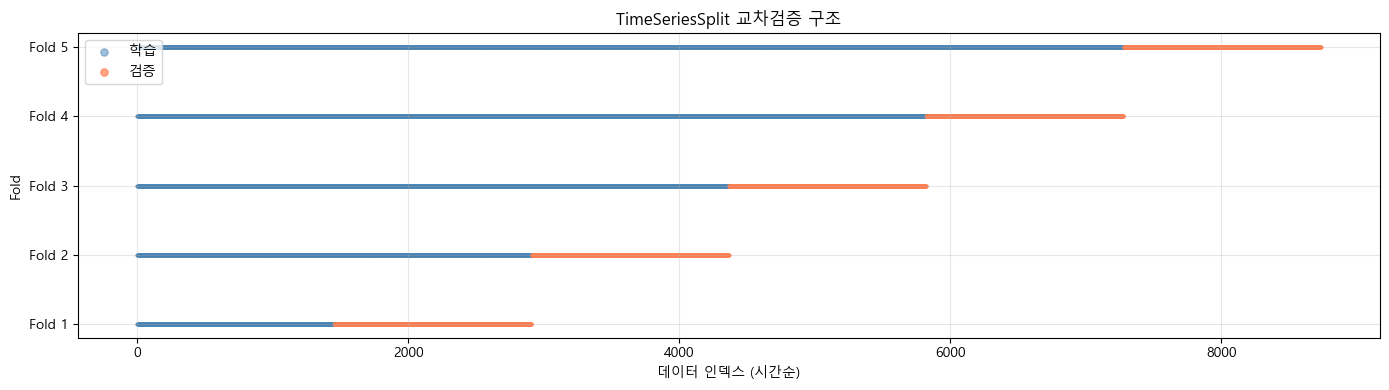

[TimeSeriesSplit 특징]
- 항상 과거 데이터(파란색)로 학습
- 항상 미래 데이터(빨간색)로 검증
- Fold가 진행될수록 학습 데이터 증가
- 실제 예측 상황과 동일한 조건에서 평가


In [45]:
# TimeSeriesSplit 시각화
fig, ax = plt.subplots(figsize=(14, 4))

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    # 학습 데이터
    ax.scatter(train_idx, [fold] * len(train_idx), c='steelblue', s=3, 
               label='학습' if fold == 0 else None, alpha=0.5)
    # 검증 데이터
    ax.scatter(val_idx, [fold] * len(val_idx), c='coral', s=3, 
               label='검증' if fold == 0 else None, alpha=0.7)

ax.set_xlabel('데이터 인덱스 (시간순)')
ax.set_ylabel('Fold')
ax.set_yticks(range(n_splits))
ax.set_yticklabels([f'Fold {i+1}' for i in range(n_splits)])
ax.set_title('TimeSeriesSplit 교차검증 구조')
ax.legend(loc='upper left', markerscale=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("[TimeSeriesSplit 특징]")
print("- 항상 과거 데이터(파란색)로 학습")
print("- 항상 미래 데이터(빨간색)로 검증")
print("- Fold가 진행될수록 학습 데이터 증가")
print("- 실제 예측 상황과 동일한 조건에서 평가")

## 3.7 데이터 누출이 발생했을 경우의 문제점 시뮬레이션

데이터 누출(Data Leakage)이 발생했을 때 어떤 문제가 발생하는지 실제로 확인함.

In [46]:
# 데이터 누출 시뮬레이션: shift 없이 Rolling 특성 생성
print("[데이터 누출 시뮬레이션]")
print("="*60)
print("시나리오: Rolling 특성 생성 시 shift()를 적용하지 않음")
print("         -> 현재 값이 특성에 포함되어 미래 정보 누출!")
print()

# 누출된 특성 생성
features_leaked = pd.DataFrame(index=df.index)

# 날짜 특성 (동일)
for col in date_cols:
    if col in features.columns:
        features_leaked[col] = features[col]

# Lag 특성 (동일 - 안전)
for col in lag_cols:
    features_leaked[col] = features[col]

# Rolling 특성 - shift 없이 (누출!)
for col in sensor_cols:
    for window in windows:
        # 잘못된 방법: shift 없이 rolling
        features_leaked[f'{col}_ma_{window}'] = df[col].rolling(window).mean()
        features_leaked[f'{col}_std_{window}'] = df[col].rolling(window).std()

# 타겟
features_leaked['target'] = df[TARGET_COL]

# 정제
features_leaked_clean = features_leaked.dropna()

# 동일한 조건으로 분할
X_leaked = features_leaked_clean.drop('target', axis=1)
y_leaked = features_leaked_clean['target']

X_train_leaked = X_leaked[X_leaked.index < SPLIT_DATE]
X_test_leaked = X_leaked[X_leaked.index >= SPLIT_DATE]
y_train_leaked = y_leaked[y_leaked.index < SPLIT_DATE]
y_test_leaked = y_leaked[y_leaked.index >= SPLIT_DATE]

# 누출된 데이터로 학습
rf_leaked = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_leaked.fit(X_train_leaked, y_train_leaked)

y_train_pred_leaked = rf_leaked.predict(X_train_leaked)
y_test_pred_leaked = rf_leaked.predict(X_test_leaked)

# 평가
train_metrics_leaked = calculate_metrics(y_train_leaked.values, y_train_pred_leaked)
test_metrics_leaked = calculate_metrics(y_test_leaked.values, y_test_pred_leaked)

[데이터 누출 시뮬레이션]
시나리오: Rolling 특성 생성 시 shift()를 적용하지 않음
         -> 현재 값이 특성에 포함되어 미래 정보 누출!



In [47]:
# 정상 vs 누출 비교
print("[정상 모델 vs 누출 모델 비교]")
print("="*70)
print(f"{'지표':<15} {'정상 (Train)':<15} {'정상 (Test)':<15} {'누출 (Train)':<15} {'누출 (Test)':<15}")
print("-"*70)
print(f"{'R²':<15} {train_metrics['R2']:<15.4f} {test_metrics['R2']:<15.4f} {train_metrics_leaked['R2']:<15.4f} {test_metrics_leaked['R2']:<15.4f}")
print(f"{'MAPE (%)':<15} {train_metrics['MAPE']:<15.2f} {test_metrics['MAPE']:<15.2f} {train_metrics_leaked['MAPE']:<15.2f} {test_metrics_leaked['MAPE']:<15.2f}")
print(f"{'MAE':<15} {train_metrics['MAE']:<15.4f} {test_metrics['MAE']:<15.4f} {train_metrics_leaked['MAE']:<15.4f} {test_metrics_leaked['MAE']:<15.4f}")

print("\n[분석]")
print("- 누출 모델의 학습 데이터 성능이 비정상적으로 높음")
print("- 이는 현재 값이 Rolling 평균에 포함되어 '답을 미리 알고 있는' 상태")
print("- 실제 배포 시 테스트 성능처럼 저하될 수 있음")
print("\n결론: 반드시 shift(1)을 먼저 적용해야 함!")

[정상 모델 vs 누출 모델 비교]
지표              정상 (Train)      정상 (Test)       누출 (Train)      누출 (Test)      
----------------------------------------------------------------------
R²              0.4582          0.0212          0.9948          0.9621         
MAPE (%)        5.33            7.14            0.40            1.07           
MAE             8.9467          12.1020         0.6855          1.8088         

[분석]
- 누출 모델의 학습 데이터 성능이 비정상적으로 높음
- 이는 현재 값이 Rolling 평균에 포함되어 '답을 미리 알고 있는' 상태
- 실제 배포 시 테스트 성능처럼 저하될 수 있음

결론: 반드시 shift(1)을 먼저 적용해야 함!


# 핵심 정리

## 시계열 데이터 분석 핵심 개념

| 개념 | 설명 | 중요도 |
|------|------|:------:|
| 시간 의존성 | 현재 값이 과거 값에 영향받음 | 높음 |
| 자기상관 | 시차별 자기 자신과의 상관관계 | 높음 |
| 계절성 | 일정 주기로 반복되는 패턴 | 높음 |
| 추세 | 장기적인 증가/감소 경향 | 중간 |
| 정상성 | 평균/분산이 시간에 따라 일정한지 여부 | 중간 |

## 수학적 배경

| 기법 | 수식 | 용도 |
|------|------|------|
| 이동평균 | $MA_t = \frac{1}{n}\sum_{i=0}^{n-1} X_{t-i}$ | 노이즈 제거, 추세 파악 |
| 지수평활 | $S_t = \alpha X_t + (1-\alpha)S_{t-1}$ | 최근 값 가중 평활화 |
| 자기상관 | $\rho_k = \frac{Cov(X_t, X_{t-k})}{Var(X_t)}$ | 시차별 상관관계 측정 |

## 평가 지표

| 지표 | 해석 기준 |
|------|----------|
| MAE | 작을수록 좋음, 단위가 원본과 동일 |
| RMSE | 큰 오차에 민감, 단위가 원본과 동일 |
| MAPE | 5% 미만 우수, 10% 미만 양호 |
| R² | 1에 가까울수록 좋음, 0.9 이상 우수 |

## 데이터 누출 방지 체크리스트

| 항목 | 올바른 방법 | 잘못된 방법 |
|------|------------|------------|
| Lag 특성 | `df['lag_1'] = df['value'].shift(1)` | `df['lag_1'] = df['value']` |
| Rolling 특성 | `df['value'].shift(1).rolling(7).mean()` | `df['value'].rolling(7).mean()` |
| 데이터 분할 | 시간 기준 분할 | 랜덤 분할 |
| 교차검증 | `TimeSeriesSplit` | `KFold` |